In [249]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly as plty
import math
import geoip2.database
from user_agents import parse

In [265]:

df = pd.read_csv("./data/processed_data/cybersecurity_attacks_processed.csv")

In [ ]:
df = pd.read_csv("./data/int/cybersecurity_attacks.csv")

In [216]:
df

,Timestamp,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Malware Indicators,Anomaly Scores,Alerts/Warnings,...,Destination Port_Cat,Year,Month,Day,Hours_div,GeoLoc_Country,GeoLoc_Country1,Packet_Length_Quartile,Day_Number,Is_Weekend
0,2023-05-30 06:33:58,31225,17616,ICMP,503,Data,HTTP,1,28.67,0,...,Registered,2023,5,30,2,India,India,Q2: 426-789,1,Weekday
1,2020-08-26 07:08:30,17245,48166,ICMP,1174,Data,HTTP,1,51.50,0,...,Registered,2020,8,26,2,India,India,Q4: 1151-1500,2,Weekday
2,2022-11-13 08:23:25,16811,53600,UDP,306,Control,HTTP,1,87.42,1,...,Dynamic,2022,11,13,2,India,India,Q1: 64-425,6,Weekend
3,2023-07-02 10:38:46,20018,32534,UDP,385,Data,HTTP,0,15.79,1,...,Registered,2023,7,2,2,India,India,Q1: 64-425,6,Weekend
4,2023-07-16 13:11:07,6131,26646,TCP,1462,Data,DNS,0,0.52,1,...,Registered,2023,7,16,3,India,India,Q4: 1151-1500,6,Weekend
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,2023-05-26 14:08:42,31005,6764,UDP,1428,Control,HTTP,1,39.28,0,...,Registered,2023,5,26,3,India,India,Q4: 1151-1500,4,Weekday
39996,2023-03-27 00:38:27,2553,28091,UDP,1184,Control,HTTP,1,27.25,0,...,Registered,2023,3,27,1,India,India,Q4: 1151-1500,0,Weekday
39997,2022-03-31 01:45:49,22505,25152,UDP,1043,Data,DNS,1,31.01,0,...,Registered,2022,3,31,1,India,India,Q3: 790-1150,3,Weekday
39998,2023-09-22 18:32:38,20013,2703,UDP,483,Data,FTP,1,97.85,1,...,Registered,2023,9,22,4,India,India,Q2: 426-789,4,Weekday


In [ ]:
df.describe()

In [215]:
df.drop(columns=['Source IP Address', 'Destination IP Address'], inplace=True)

In [ ]:
df.isna().sum()

In [ ]:
df.columns

In [ ]:
# Count Device Information that occured >= 30 times
df.value_counts("Device Information")[df.value_counts("Device Information") >= 30]

In [ ]:
df['Browser_family'] = df['Device Information'].apply(lambda x: parse(x).browser.family if parse(x).browser.family is not None else pd.NA)
df['Browser_major'] = df['Device Information'].apply(lambda x: parse(x).browser.version[0] if parse(x).browser.version[0] is not None else pd.NA)
df['Browser_minor'] = df['Device Information'].apply(lambda x: parse(x).browser.version[1] if parse(x).browser.version[1] is not None else pd.NA)
df['OS_family'] = df['Device Information'].apply(lambda x: parse(x).os.family if parse(x).os.family is not None else pd.NA)
df['OS_major'] = df['Device Information'].apply(
    lambda x: parse(x).os.version[0] if len(parse(x).os.version) > 0 and parse(x).os.version[0] is not None else pd.NA
)
df['OS_minor'] = df['Device Information'].apply(
    lambda x: parse(x).os.version[1] if len(parse(x).os.version) > 1 and parse(x).os.version[1] is not None else pd.NA
)
df['OS_patch'] = df['Device Information'].apply(
    lambda x: parse(x).os.version[2] if len(parse(x).os.version) > 2 and parse(x).os.version[2] is not None else pd.NA
)
df['Device_family'] = df['Device Information'].apply(lambda x: parse(x).device.family if parse(x).device.family is not None else pd.NA)
df['Device_brand'] = df['Device Information'].apply(lambda x: parse(x).device.brand if parse(x).device.brand is not None else pd.NA)

In [ ]:
df['OS_major'] = df['OS_major'].fillna('not specified')
df['OS_minor'] = df['OS_minor'].fillna('not specified')
df['OS_patch'] = df['OS_patch'].fillna('not specified')
df['Device_brand'] = df['Device_brand'].fillna('not specified')

In [ ]:
df[['OS_family','OS_major', 'OS_minor', 'OS_patch', 'Browser_major', 'Browser_minor', 'Browser_family', 'Device_family', 'Device_brand']].isna().sum()
# df[['OS_family','OS_major', 'Browser_major', 'Browser_family', 'Device_family']].isna().sum()

In [ ]:
# OS_major has 7171 missing values
df.drop(columns='OS_major', inplace=True)

In [ ]:
# drop feature OS_minor, OS_patch, Device_brand as it has too many missing values (25k, 29k, 23k respectively), also to reduce dimensionality
# also noise or overfitting?
# df = df.drop(columns=['OS_minor', 'OS_patch', 'Device_brand'])
# df = df.drop(columns=['Device_brand'])

In [ ]:
df[['OS_family','OS_major', 'Browser_major', 'Browser_family', 'Device_family']].nunique(dropna=False)

In [ ]:
df_concatDeviceCheck = pd.DataFrame()
df_concatDeviceCheck['OS_family_major'] = df['OS_family'].astype(str) + " " + df['OS_major'].astype(str)


In [ ]:
df_concatDeviceCheck['Browser_family_major'] = df['Browser_family'].astype(str) + " " + df['Browser_major'].astype(str)
df_concatDeviceCheck['Browser_family_major_minor'] = df['Browser_family'].astype(str) + " " + df['Browser_major'].astype(str) + " " + df['Browser_minor'].astype(str)


In [ ]:
#33 combination of OS_family and OS_major
df_concatDeviceCheck['OS_family_major'].value_counts()

In [ ]:
#200 combination of Browser_family and Browser_major
df_concatDeviceCheck['Browser_family_major'].value_counts()

In [ ]:
#473 combination of Browser_family and Browser_major
df_concatDeviceCheck['Browser_family_major_minor'].value_counts()

In [ ]:
df_concatDeviceCheck['Attack Type'] = df['Attack Type']

In [ ]:
df_concatDeviceCheck['Browser_family'] = df['Browser_family']
df_concatDeviceCheck['OS_family'] = df['OS_family']
df_concatDeviceCheck['Device_family'] = df['Device_family']

In [ ]:
df_concatDeviceCheck.columns

In [ ]:
df_concatDeviceCheck.head(5)

In [ ]:
# Some OS_family_major show more frequently attacked however fairly distributed to Attack Type
top_n = 10
top_os = df_concatDeviceCheck['OS_family_major'].value_counts().head(top_n).index
df_top = df_concatDeviceCheck[df_concatDeviceCheck['OS_family_major'].isin(top_os)]

plt.figure(figsize=(14, 6))
sns.histplot(
    x="OS_family_major",
    hue="Attack Type",
    multiple="stack",
    data=df_top
)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Some Browser_family_major_minor show more frequently attacked however fairly distributed to Attack Type
top_n = 10
top_os = df_concatDeviceCheck['Browser_family_major_minor'].value_counts().head(top_n).index
df_top = df_concatDeviceCheck[df_concatDeviceCheck['Browser_family_major_minor'].isin(top_os)]

plt.figure(figsize=(14, 6))
sns.histplot(
    x="Browser_family_major_minor",
    hue="Attack Type",
    multiple="stack",
    data=df_top
)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Some Browser_family_major show more frequently attacked however fairly distributed to Attack Type
top_n = 10
top_os = df_concatDeviceCheck['Browser_family_major'].value_counts().head(top_n).index
df_top = df_concatDeviceCheck[df_concatDeviceCheck['Browser_family_major'].isin(top_os)]

plt.figure(figsize=(14, 6))
sns.histplot(
    x="Browser_family_major",
    hue="Attack Type",
    multiple="stack",
    data=df_top
)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Some OS_family_major show more frequently attacked however fairly distributed to Attack Type
top_n = 10
top_os = df_concatDeviceCheck['OS_family'].value_counts().head(top_n).index
df_top = df_concatDeviceCheck[df_concatDeviceCheck['OS_family'].isin(top_os)]

plt.figure(figsize=(14, 6))
sns.histplot(
    x="OS_family",
    hue="Attack Type",
    multiple="stack",
    data=df_top
)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Some Browser_family show more frequently attacked however fairly distributed to Attack Type
top_n = 10
top_os = df_concatDeviceCheck['Browser_family'].value_counts().head(top_n).index
df_top = df_concatDeviceCheck[df_concatDeviceCheck['Browser_family'].isin(top_os)]

plt.figure(figsize=(14, 6))
sns.histplot(
    x="Browser_family",
    hue="Attack Type",
    multiple="stack",
    data=df_top
)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Some Device_family show more frequently attacked however fairly distributed to Attack Type
top_n = 10
top_os = df_concatDeviceCheck['Device_family'].value_counts().head(top_n).index
df_top = df_concatDeviceCheck[df_concatDeviceCheck['Device_family'].isin(top_os)]

plt.figure(figsize=(14, 6))
sns.histplot(
    x="Device_family",
    hue="Attack Type",
    multiple="stack",
    data=df_top
)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# ("Jamshedpur, Sikkim").split(",")[0]
df["GeoLoc_City1"] = df["Geo-location Data"].apply(lambda x: x.split(",")[0].strip())

In [ ]:
df["GeoLoc_City2"] = df["Geo-location Data"].apply(lambda x: x.split(",")[-1].strip())

In [ ]:
df.columns

In [ ]:
from user_agents import parse as ua_parse

def deviceType(ua_string):
    try:
        if not ua_string or pd.isna(ua_string):
            return pd.NA
        ua = ua_parse(ua_string)           # user_agents.parse -> object with is_mobile/is_tablet/is_pc
        if getattr(ua, "is_mobile", False):
            return "Mobile"
        if getattr(ua, "is_tablet", False):
            return "Tablet"
        if getattr(ua, "is_pc", False):
            return "PC"
        return "Unknown"
    except Exception:
        return "Unknown"

# apply
df['Device_type'] = df['Device Information'].apply(deviceType)
# deviceType("Mozilla/5.0 (iPhone; CPU iPhone OS 5_1_1 like Mac OS X) AppleWebKit/533.0 (KHTML, like Gecko) CriOS/51.0.844.0 Mobile/22B509 Safari/533.0")

In [ ]:
# no bot detected
df['is_bot'] = df['Device Information'].apply(lambda x: ua_parse(x).is_bot)
ua_parse("Mozilla/5.0 (compatible; Googlebot/2.1; +http://www.google.com/bot.html)").is_bot

In [ ]:
df_concatDeviceCheck['Device_type'] = df['Device_type']

In [ ]:
# Some Device_type show more frequently attacked however fairly distributed to Attack Type
top_n = 10
top_os = df_concatDeviceCheck['Device_type'].value_counts().head(top_n).index
df_top = df_concatDeviceCheck[df_concatDeviceCheck['Device_type'].isin(top_os)]

plt.figure(figsize=(14, 6))
sns.histplot(
    x="Device_type",
    hue="Attack Type",
    multiple="stack",
    data=df_top
)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# display non-numeric columns
df.select_dtypes(exclude=[np.number]).columns.tolist()

In [ ]:
# ASK: only 1 destionation IP appears in source IPs, what does this mean? cause both looks inbound traffic.
# find destination IPs that appear in Source IPs without modifying df
destIPinSourceIP = df['Destination IP Address'].isin(df['Source IP Address'])
matched_rows = df[destIPinSourceIP].copy()  # recuperate whole rows
matched_rows

# df.drop(columns=['Dest_in_Source'])

In [ ]:
# take the first three octets of the IP as a list
split = "103.216.15.12".split(".")[:3]
ip3 = ".".join(split)
ip3

In [ ]:
# Split all IPs to /24 subnet ==> local subnet/Single host
def splitIP24(ip):
    if pd.isna(ip):
        return pd.NA
    return ".".join(ip.split(".")[:3])

# Split all IPs to /16 subnet ==> network owner/region (ISP/backbone provider)
def splitIP16(ip):
    if pd.isna(ip):
        return pd.NA
    return ".".join(ip.split(".")[:2])

df['Source IP Address_24'] = df['Source IP Address'].apply(splitIP24)
df['Source IP Address_16'] = df['Source IP Address'].apply(splitIP16)

df['Destination IP Address_24'] = df['Destination IP Address'].apply(splitIP24)
df['Destination IP Address_16'] = df['Destination IP Address'].apply(splitIP16)

df['Proxy Information_24'] = df['Proxy Information'].apply(splitIP24)
df['Proxy Information_16'] = df['Proxy Information'].apply(splitIP16)


In [ ]:
# Check private range
# • 10.0.0.0 – 10.255.255.255 
# • 172.16.0.0 – 172.31.255.255 
# • 192.168.0.0 – 192.168.255.255

def isPrivateIP(ip):
    if pd.isna(ip):
        return pd.NA
    octets = ip.split(".")
    first = int(octets[0])
    second = int(octets[1])
    if first == 10:
        return True
    elif first == 172 and 16 <= second <= 31:
        return True
    elif first == 192 and second == 168:
        return True
    else:
        return False

df['isPrivate_Source'] = df['Source IP Address'].apply(isPrivateIP)
df['isPrivate_Destination'] = df['Destination IP Address'].apply(isPrivateIP)
df['isPrivate_Proxy'] = df['Proxy Information'].apply(isPrivateIP)

In [ ]:
df['useProxy'] = df['Proxy Information'].apply(lambda x: False if pd.isna(x) else True)

In [ ]:
df['useProxy'].value_counts(dropna=False)

In [ ]:
df['Proxy_isPrivate'].value_counts(dropna=False)


In [ ]:
df['isPrivate_Proxy'] = df['isPrivate_Proxy'].apply(lambda x: 'noProxy' if pd.isna(x) else x)
df['isPrivate_Proxy'].value_counts(dropna=False)

In [ ]:
with geoip2.database.Reader('./data/ext/GeoLite2-Country_20251212/GeoLite2-Country.mmdb') as reader:
    response = reader.country(df.loc[0, 'Source IP Address'])
    print(response)
    # print(response.continent.names)

In [ ]:
df_test = df.head(2)
df_test

In [ ]:
import geoip2.errors
with geoip2.database.Reader('./data/ext/GeoLite2-Country_20251212/GeoLite2-Country.mmdb') as reader:
    def _lookup_ip(ip):
        # 1. Handle missing/NA values
        if not ip or pd.isna(ip):
            return {
                'ContinentName': pd.NA,
                'CountryName': pd.NA,
            }
        
        # 2. Perform external lookup
        try:
            response = reader.country(ip)
            
            # 3. RETURN A DICTIONARY of all desired features
            return {
                'ContinentName': response.continent.name,
                'CountryName': response.country.name,
            }
        
        except geoip2.errors.AddressNotFoundError:
            # 4. Return NA dictionary for not found IPs
            return {
                'ContinentName': pd.NA,
                'CountryName': pd.NA,
            }
        except Exception:
            # 5. Return NA dictionary for other errors
            return {
                'ContinentName': pd.NA,
                'CountryName': pd.NA,
            }

    # --- Applying the Function ---
    geo_results_sourceIP = df['Source IP Address'].apply(_lookup_ip)
    geo_results_destIP = df['Destination IP Address'].apply(_lookup_ip)
    geo_results_proxyIP = df['Proxy Information'].apply(_lookup_ip)

    # print('geo_results_sourceIP', geo_results_sourceIP)
    # Convert list of dictionaries to DataFrame
    geo_df_sourceIP = pd.DataFrame(geo_results_sourceIP.tolist(), index=geo_results_sourceIP.index)
    # print('geo_df_sourceIP', geo_df_sourceIP)
    geo_df_destIP = pd.DataFrame(geo_results_destIP.tolist(), index=geo_results_destIP.index)
    # print('geo_df_destIP', geo_df_destIP)

    geo_df_proxyIP = pd.DataFrame(geo_results_proxyIP.tolist(), index=geo_results_proxyIP.index)

    # test to df_test before real df
    # df_test.loc[:, ('ContinentName_Source', 'CountryName_Source')] = geo_df_sourceIP[['ContinentName', 'CountryName']]
    # Source IP
    df['ContinentName_Source'] = geo_df_sourceIP['ContinentName']
    df['CountryName_Source'] = geo_df_sourceIP['CountryName']
    # df.loc[:, ('ContinentName_Source', 'CountryName_Source')] = geo_df_sourceIP[['ContinentName', 'CountryName']]
    # print('am here')
    
    # Destination IP
    df['ContinentName_Destination'] = geo_df_destIP['ContinentName']
    df['CountryName_Destination'] = geo_df_destIP['CountryName']

    # Proxy IP
    df['ContinentName_Proxy'] = geo_df_proxyIP['ContinentName']
    df['CountryName_Proxy'] = geo_df_proxyIP['CountryName']

In [ ]:
import geoip2.errors
with geoip2.database.Reader('./data/ext/GeoLite2-City_20251212/GeoLite2-City.mmdb') as reader:
    def _lookup_ip(ip):
        # 1. Handle missing/NA values
        if not ip or pd.isna(ip):
            return {
                'CityName': pd.NA,
                # 'CityLat_Source': pd.NA,
                # 'CityLon': pd.NA,
            }
        
        # 2. Perform external lookup
        try:
            response = reader.city(ip)
            
            # 3. RETURN A DICTIONARY of all desired features
            return {
                    'CityName': response.city.name,
                    # 'CityLat': response.location.latitude,
                    # 'CityLon': response.location.longitude,
            }
        
        except geoip2.errors.AddressNotFoundError:
            # 4. Return NA dictionary for not found IPs
            return {
                'CityName': pd.NA,
                # 'CityLat': pd.NA,
                # 'CityLon': pd.NA,
                # 'ASN': pd.NA,
                # 'Is_Private': False
            }
        except Exception:
            # 5. Return NA dictionary for other errors
            return {
                'CityName': pd.NA,
                # 'CityLat': pd.NA,
                # 'CityLon': pd.NA,
                # 'ASN': pd.NA,
                # 'Is_Private': False
            }

    # --- Applying the Function ---
    geo_results_sourceIP = df['Source IP Address'].apply(_lookup_ip)
    geo_results_destIP = df['Destination IP Address'].apply(_lookup_ip)
    geo_results_proxyIP = df['Proxy Information'].apply(_lookup_ip)

    # print(geo_results_sourceIP)
    # Convert list of dictionaries to DataFrame
    geo_df_sourceIP = pd.DataFrame(geo_results_sourceIP.tolist(), index=geo_results_sourceIP.index)
    geo_df_destIP = pd.DataFrame(geo_results_destIP.tolist(), index=geo_results_destIP.index)
    geo_df_proxyIP = pd.DataFrame(geo_results_proxyIP.tolist(), index=geo_results_proxyIP.index)
    # print(geo_df_sourceIP)

    # test to df_test before real df
    # df_test.loc[:, ('CityName_Source', 'CityLat_Source', 'CityLon_Source')] = geo_df[['CityName_Source', 'CityLat_Source', 'CityLon_Source']]
    df['CityName_Proxy'] = geo_df_proxyIP['CityName']
    # df['CityLat_Proxy'] = geo_df_proxyIP['CityLat']
    # df['CityLon_Proxy'] = geo_df_proxyIP['CityLon']

    df['CityName_Destination'] = geo_df_destIP['CityName']
    # df['CityLat_Destination'] = geo_df_destIP['CityLat']
    # df['CityLon_Destination'] = geo_df_destIP['CityLon']

    df['CityName_Source'] = geo_df_sourceIP['CityName']
    # df['CityLat_Source'] = geo_df_sourceIP['CityLat']
    # df['CityLon_Source'] = geo_df_sourceIP['CityLon']

    # why codes below didnt work??
    # df.loc[:, ('CityName_Source', 'CityLat_Source', 'CityLon_Source')] = geo_df_sourceIP[['CityName', 'CityLat', 'CityLon']]
    # df.loc[:, ('CityName_Destination', 'CityLat_Destination', 'CityLon_Destination')] = geo_df_destIP[['CityName', 'CityLat', 'CityLon']]
    # df.loc[:, ('CityName_Proxy', 'CityLat_Proxy', 'CityLon_Proxy')] = geo_df_proxyIP[['CityName', 'CityLat', 'CityLon']]

In [ ]:
import geoip2.errors
try:
    with geoip2.database.Reader('./data/ext/GeoLite2-ASN_20251214/GeoLite2-ASN.mmdb') as reader:  # Use ASN database
        def _lookup_ip(ip):
            # 1. Handle missing/NA values
            if not ip or pd.isna(ip):
                return {
                    'ASN': pd.NA,
                }
            
            # 2. Perform external lookup
            try:
                response = reader.asn(ip)  # Use asn() method for ASN database
                
                # 3. RETURN A DICTIONARY of all desired features
                return {
                    'ASN': response.autonomous_system_number,
                }
            
            except geoip2.errors.AddressNotFoundError:
                # 4. Return NA dictionary for not found IPs
                return {
                    'ASN': pd.NA,
                }
            except Exception:
                # 5. Return NA dictionary for other errors
                return {
                    'ASN': pd.NA,
                }

        # --- Applying the Function ---
        geo_results_sourceIP = df['Source IP Address'].apply(_lookup_ip)
        geo_results_destIP = df['Destination IP Address'].apply(_lookup_ip)
        geo_results_proxyIP = df['Proxy Information'].apply(_lookup_ip)

        # Convert list of dictionaries to DataFrame
        geo_df_sourceIP = pd.DataFrame(geo_results_sourceIP.tolist(), index=geo_results_sourceIP.index)
        geo_df_destIP = pd.DataFrame(geo_results_destIP.tolist(), index=geo_results_destIP.index)
        geo_df_proxyIP = pd.DataFrame(geo_results_proxyIP.tolist(), index=geo_results_proxyIP.index)

        # Source IP
        df['ASN_source'] = geo_df_sourceIP['ASN']
        
        # Destination IP
        df['ASN_destination'] = geo_df_destIP['ASN']

        # Proxy IP
        df['ASN_proxy'] = geo_df_proxyIP['ASN']
except FileNotFoundError:
    # If the ASN database file is not found, set ASN columns to pd.NA
    df['ASN_source'] = pd.NA
    df['ASN_destination'] = pd.NA
    df['ASN_proxy'] = pd.NA

In [ ]:
with geoip2.database.Reader('./data/ext/GeoLite2-City_20251212/GeoLite2-City.mmdb') as reader:
    response = reader.city(df.loc[0, 'Source IP Address'])
    print(response)
    print(response.city.name)
    print(response.location.latitude)
    print(response.location.longitude)
    # print(response.postal.code)

In [ ]:
grouped = df.groupby('Source_IP_Private')['Attack Type'].value_counts()
percentages = (grouped / grouped.groupby(level=0).sum()) * 100
print(percentages)
print(grouped)

In [ ]:
grouped = df.groupby('useProxy')['Attack Type'].value_counts()
percentages = (grouped / grouped.groupby(level=0).sum()) * 100
print(percentages)
print(grouped)

In [ ]:
# 8333 unique same source ports appear more than once
# of total 29761 source ports, means around 30%
# Maybe can't use this cause when we divide the dataset in train/test, we won't have same result of frequency of source port appearing
df['Source Port'].value_counts()[df['Source Port'].value_counts() > 1]

In [ ]:
# 8217 unique destination ports appear more than once
# of total 29895 unique destination ports, means around 27.5%
# Maybe can't use this cause when we divide the dataset in train/test, we won't have same result of frequency of destination port appearing
df['Destination Port'].value_counts()[df['Destination Port'].value_counts() > 1]

In [ ]:
# df['Destination Port'].nunique() # 29895 unique destination ports
df['Source Port'].nunique() # 29761 unique source ports

In [ ]:
# Treat ports
# HTTPS 443, SSH 22, DNS 53, FTP 20-21) 
# Well-known (0–1023) → common services (HTTP, FTP, DNS, etc.) 
# User/Registered Ports (1024-49151) → used by Server, Application, Database, VPN (HTTP alternate 8080, MySQL 3306) 
# Dynamic and/or Private Ports (49152-65535) → temporary/ephemeral ports for outgoing connections, used by Clients. Rapid rotation may signal botnets. 
# Plot to see distribution of these different ports vs packet length 
# Also vs protocol/traffic type/attack type, etc ? Any meaning? 
def portCategory(port):
    if pd.isna(port):
        return pd.NA
    elif 0 <= port <= 1023:
        return 'Wellknown'
    elif 1024 <= port <= 49151:
        return 'Registered'
    elif 49152 <= port <= 65535:
        return 'Dynamic'
    else:
        return 'Invalid'

df['Source Port_Cat'] = df['Source Port'].apply(portCategory)
df['Destination Port_Cat'] = df['Destination Port'].apply(portCategory)

In [ ]:
df.groupby('Source Port')['Attack Type'].value_counts().sort_values(ascending=False)

In [ ]:
ct = pd.crosstab(df['Source Port'], [df['Source Port_Cat'], df['Attack Type']])
ct['Total'] = ct.sum(axis=1)
ct = ct.sort_values('Total', ascending=False).drop('Total', axis=1)
ct

In [ ]:
ct = pd.crosstab(df['Source Port_Cat'], [df['Attack Type']])
ct['Total'] = ct.sum(axis=1)
ct = ct.sort_values('Total', ascending=False).drop('Total', axis=1)
ct

In [ ]:
df['Source Port'].value_counts().sort_values(ascending=False)

In [ ]:
df['Source Port_Cat'].value_counts().sort_values(ascending=False)

In [ ]:
df['Destination Port_Cat'].value_counts().sort_values(ascending=False)

In [ ]:
ct = pd.crosstab(df['Destination Port_Cat'], [df['Attack Type'], df['Severity Level']])
ct['Total'] = ct.sum(axis=1)
ct = ct.sort_values('Total', ascending=False).drop('Total', axis=1)
ct

In [ ]:
sns.displot(x='Source Port_Cat', hue='Attack Type', multiple='stack', col='Alerts/Warnings', data=df)
plt.show()

In [ ]:
sns.displot(x='Source Port_Cat', hue='Attack Type', multiple='stack', data=df)
plt.show()

In [ ]:
sns.displot(x='Destination Port_Cat', hue='Attack Type', multiple='stack', data=df)
plt.show()

In [ ]:
# How to treat timestamps?
# # # Timeseries?
df['Year'] = df['Timestamp'].apply(lambda x: pd.to_datetime(x).year)
df['Month'] = df['Timestamp'].apply(lambda x: pd.to_datetime(x).month)
df['Day'] = df['Timestamp'].apply(lambda x: pd.to_datetime(x).day)
# https://www.indialawoffices.com/legal-articles/work-hours-and-office-timing-in-india
# Daily working hours range from 8-10 hours.
# 8 to 7 (pause 1h) - 10h (assumption)
df['Hours_div'] = pd.to_datetime(df['Timestamp']).apply(
    lambda x: 1 if 0 <= x.hour <= 5 else
              2 if 6 <= x.hour <= 11 else
              3 if 12 <= x.hour <= 17 else
              4 # for 18-23
)
# print(pd.to_datetime(df.loc[0, 'Timestamp']).hour)
# print(pd.to_datetime(df.loc[0, 'Timestamp']))

# pd.to_datetime(df.loc[6, 'Timestamp']).year

In [ ]:
df['Malware Indicators'].unique() # Only has 2 values: IoC Detected (1), nan (0)
df['Malware Indicators'] = df['Malware Indicators'].apply(lambda x: 0 if pd.isna(x) else 1)

In [ ]:
df['Alerts/Warnings'].unique() # # Only has 2 values: Alert Triggered (1), nan (0)
df['Alerts/Warnings'] = df['Alerts/Warnings'].apply(lambda x: 0 if pd.isna(x) else 1)


In [ ]:
df['IDS/IPS Alerts'].unique() # # Only has 2 values: Alert Triggered (1), nan (0)
df['IDS/IPS Alerts'] = df['IDS/IPS Alerts'].apply(lambda x: 0 if pd.isna(x) else 1)

In [ ]:
df['Firewall Logs'].unique() # # Only has 2 values: Alert Triggered (1), nan (0)
df['Firewall Logs'] = df['Firewall Logs'].apply(lambda x: 0 if pd.isna(x) else 1)

In [ ]:
df['Proxy Information'] = df['Proxy Information'].apply(lambda x: 'noProxy' if pd.isna(x) else x)
df['Proxy Information_24'] = df['Proxy Information_24'].apply(lambda x: 'noProxy' if pd.isna(x) else x)
df['Proxy Information_16'] = df['Proxy Information_16'].apply(lambda x: 'noProxy' if pd.isna(x) else x)
df['isPrivate_Proxy'] = df['isPrivate_Proxy'].apply(lambda x: 'noProxy' if pd.isna(x) else x)

In [ ]:
df['ContinentName_Destination'] = df['ContinentName_Destination'].apply(lambda x: "not identified" if pd.isna(x) else x)
df['CountryName_Destination'] = df['CountryName_Destination'].apply(lambda x: "not identified" if pd.isna(x) else x)
df['ContinentName_Source'] = df['ContinentName_Source'].apply(lambda x: "not identified" if pd.isna(x) else x)
df['CountryName_Source'] = df['CountryName_Source'].apply(lambda x: "not identified" if pd.isna(x) else x)


In [ ]:
df['CityName_Destination'] = df['CityName_Destination'].apply(lambda x: "not identified" if pd.isna(x) else x)
df['CityName_Source'] = df['CityName_Source'].apply(lambda x: "not identified" if pd.isna(x) else x)
df['CityName_Proxy'] = df['CityName_Proxy'].apply(lambda x: "not identified" if pd.isna(x) else x)

In [ ]:
df.loc[df['Proxy Information'] == 'noProxy', 'ContinentName_Proxy'] = 'noProxy'
df.loc[df['Proxy Information'] == 'noProxy', 'CountryName_Proxy'] = 'noProxy'

In [ ]:
df['ContinentName_Proxy'] = df['ContinentName_Proxy'].apply(lambda x: "not identified" if pd.isna(x) else x)
df['CountryName_Proxy'] = df['CountryName_Proxy'].apply(lambda x: "not identified" if pd.isna(x) else x)

In [ ]:
df['ASN_source'] = df['ASN_source'].apply(lambda x: "not identified" if pd.isna(x) else x)
df['ASN_destination'] = df['ASN_destination'].apply(lambda x: "not identified" if pd.isna(x) else x)
df['ASN_proxy'] = df['ASN_proxy'].apply(lambda x: "not identified" if pd.isna(x) else x)

In [ ]:
df

In [ ]:
# Install geopy if needed: pip install geopy

from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut, GeocoderServiceError
import time

geolocator = Nominatim(user_agent="city_to_country", timeout=3)

def get_country_from_city(city_name):
    if not city_name or pd.isna(city_name):
        return 'not identified'
    try:
        location = geolocator.geocode(city_name, timeout=3)
        if location:
            return location.address.split(',')[-1].strip()  # Extract country
        return 'not identified'
    except (GeocoderTimedOut, GeocoderServiceError):
        return 'not identified'
    except Exception:
        return 'not identified'

# OPTIMIZED: Only geocode unique city names to avoid redundant API calls
unique_cities = df['GeoLoc_City2'].dropna().unique()
print(f"Found {len(unique_cities)} unique cities to geocode")

# Create a mapping dictionary
city_to_country = {}
for i, city in enumerate(unique_cities):
    if i % 10 == 0:  # Progress update every 10 cities
        print(f"Processing {i}/{len(unique_cities)}...")
    city_to_country[city] = get_country_from_city(city)
    time.sleep(1.1)  # Respect Nominatim rate limit (1 request per second)

# Map the results to the dataframe
df['GeoLoc_Country'] = df['GeoLoc_City2'].map(city_to_country).fillna('not identified')
print(f"\nCompleted! Sample result: {get_country_from_city('Orai')}")

In [ ]:
# Install geopy if needed: pip install geopy

from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut, GeocoderServiceError
import time

geolocator = Nominatim(user_agent="city_to_country", timeout=3)

def get_country_from_city(city_name):
    if not city_name or pd.isna(city_name):
        return 'not identified'
    try:
        location = geolocator.geocode(city_name, timeout=3)
        if location:
            return location.address.split(',')[-1].strip()  # Extract country
        return 'not identified'
    except (GeocoderTimedOut, GeocoderServiceError):
        return 'not identified'
    except Exception:
        return 'not identified'

# OPTIMIZED: Only geocode unique city names to avoid redundant API calls
unique_cities = df['GeoLoc_City1'].dropna().unique()
print(f"Found {len(unique_cities)} unique cities to geocode")

# Create a mapping dictionary
city_to_country = {}
for i, city in enumerate(unique_cities):
    if i % 10 == 0:  # Progress update every 10 cities
        print(f"Processing {i}/{len(unique_cities)}...")
    city_to_country[city] = get_country_from_city(city)
    time.sleep(1.1)  # Respect Nominatim rate limit (1 request per second)

# Map the results to the dataframe
df['GeoLoc_Country1'] = df['GeoLoc_City1'].map(city_to_country).fillna('not identified')
print(f"\nCompleted! Sample result: {get_country_from_city('Noida')}")

In [ ]:
from geopy.geocoders import Nominatim
from functools import partial
geolocator = Nominatim(user_agent="city_to_country")
geocode = partial(geolocator.geocode, language="es")
print(geocode("Orai", language="en"))

In [ ]:
df.isna().sum()
#CityName_Source 21401
#CityName_Destination 21568
#CityName_Proxy 30751

In [ ]:
df.columns

In [ ]:
df

In [311]:
# Save the processed dataframe to avoid re-running all code
import os

# Create processed_data directory if it doesn't exist
os.makedirs('./data/processed_data', exist_ok=True)

# Save as CSV (recommended for most cases)
df.to_csv('./data/processed_data/cybersecurity_attacks_processed.csv', index=False)
print("DataFrame saved as CSV!")

# Alternative: Save as Pickle (preserves data types perfectly, faster to load)
df.to_pickle('./data/processed_data/cybersecurity_attacks_processed.pkl')
print("DataFrame also saved as Pickle!")

# To load it back later, use:
# df = pd.read_csv('./processed_data/cybersecurity_attacks_processed.csv')
# or
# df = pd.read_pickle('./processed_data/cybersecurity_attacks_processed.pkl')

DataFrame saved as CSV!
DataFrame also saved as Pickle!


In [310]:

# Save the processed dataframe to avoid re-running all code
import os

# Create processed_data directory if it doesn't exist
os.makedirs('./data/processed_data', exist_ok=True)

# Save as CSV (recommended for most cases)
df_for_stats.to_csv('./data/processed_data/cybersecurity_attacks_processed_for_stats.csv', index=False)
print("DataFrame saved as CSV!")

# Alternative: Save as Pickle (preserves data types perfectly, faster to load)
df_for_stats.to_pickle('./data/processed_data/cybersecurity_attacks_processed_for_stats.pkl')
print("DataFrame also saved as Pickle!")

# To load it back later, use:
# df_for_stats = pd.read_csv('./processed_data/cybersecurity_attacks_processed_for_stats.csv')
# or
# df_for_stats = pd.read_pickle('./processed_data/cybersecurity_attacks_processed_for_stats.pkl')

DataFrame saved as CSV!
DataFrame also saved as Pickle!


In [ ]:
df['useProxy'].unique()

In [ ]:
df.drop(columns=['CityName_Source','CityName_Destination','CityName_Proxy'], inplace=True)

In [3]:
df.drop(columns=['Geo-location Data', 'Device Information', 'Payload Data'])

,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Malware Indicators,...,ASN_destination,ASN_proxy,Source Port_Cat,Destination Port_Cat,Year,Month,Day,Hours_div,GeoLoc_Country,GeoLoc_Country1
0,2023-05-30 06:33:58,103.216.15.12,84.9.164.252,31225,17616,ICMP,503,Data,HTTP,1,...,25310,4685,Registered,Registered,2023,5,30,2,India,India
1,2020-08-26 07:08:30,78.199.217.198,66.191.137.154,17245,48166,ICMP,1174,Data,HTTP,1,...,20115,not identified,Registered,Registered,2020,8,26,2,India,India
2,2022-11-13 08:23:25,63.79.210.48,198.219.82.17,16811,53600,UDP,306,Control,HTTP,1,...,721,not identified,Registered,Dynamic,2022,11,13,2,India,India
3,2023-07-02 10:38:46,163.42.196.10,101.228.192.255,20018,32534,UDP,385,Data,HTTP,0,...,4812,not identified,Registered,Registered,2023,7,2,2,India,India
4,2023-07-16 13:11:07,71.166.185.76,189.243.174.238,6131,26646,TCP,1462,Data,DNS,0,...,8151,174,Registered,Registered,2023,7,16,3,India,India
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,2023-05-26 14:08:42,26.36.109.26,121.100.75.240,31005,6764,UDP,1428,Control,HTTP,1,...,18334,not identified,Registered,Registered,2023,5,26,3,India,India
39996,2023-03-27 00:38:27,17.21.163.81,196.108.134.78,2553,28091,UDP,1184,Control,HTTP,1,...,33771,4788,Registered,Registered,2023,3,27,1,India,India
39997,2022-03-31 01:45:49,162.35.217.57,98.107.0.15,22505,25152,UDP,1043,Data,DNS,1,...,22394,not identified,Registered,Registered,2022,3,31,1,India,India
39998,2023-09-22 18:32:38,208.72.233.205,173.79.112.252,20013,2703,UDP,483,Data,FTP,1,...,701,not identified,Registered,Registered,2023,9,22,4,India,India


In [5]:
df

,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Payload Data,...,ASN_destination,ASN_proxy,Source Port_Cat,Destination Port_Cat,Year,Month,Day,Hours_div,GeoLoc_Country,GeoLoc_Country1
0,2023-05-30 06:33:58,103.216.15.12,84.9.164.252,31225,17616,ICMP,503,Data,HTTP,Qui natus odio asperiores nam. Optio nobis ius...,...,25310,4685,Registered,Registered,2023,5,30,2,India,India
1,2020-08-26 07:08:30,78.199.217.198,66.191.137.154,17245,48166,ICMP,1174,Data,HTTP,Aperiam quos modi officiis veritatis rem. Omni...,...,20115,not identified,Registered,Registered,2020,8,26,2,India,India
2,2022-11-13 08:23:25,63.79.210.48,198.219.82.17,16811,53600,UDP,306,Control,HTTP,Perferendis sapiente vitae soluta. Hic delectu...,...,721,not identified,Registered,Dynamic,2022,11,13,2,India,India
3,2023-07-02 10:38:46,163.42.196.10,101.228.192.255,20018,32534,UDP,385,Data,HTTP,Totam maxime beatae expedita explicabo porro l...,...,4812,not identified,Registered,Registered,2023,7,2,2,India,India
4,2023-07-16 13:11:07,71.166.185.76,189.243.174.238,6131,26646,TCP,1462,Data,DNS,Odit nesciunt dolorem nisi iste iusto. Animi v...,...,8151,174,Registered,Registered,2023,7,16,3,India,India
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,2023-05-26 14:08:42,26.36.109.26,121.100.75.240,31005,6764,UDP,1428,Control,HTTP,Quibusdam ullam consequatur consequuntur accus...,...,18334,not identified,Registered,Registered,2023,5,26,3,India,India
39996,2023-03-27 00:38:27,17.21.163.81,196.108.134.78,2553,28091,UDP,1184,Control,HTTP,Quaerat neque esse. Animi expedita natus commo...,...,33771,4788,Registered,Registered,2023,3,27,1,India,India
39997,2022-03-31 01:45:49,162.35.217.57,98.107.0.15,22505,25152,UDP,1043,Data,DNS,Enim at aspernatur illum. Saepe numquam eligen...,...,22394,not identified,Registered,Registered,2022,3,31,1,India,India
39998,2023-09-22 18:32:38,208.72.233.205,173.79.112.252,20013,2703,UDP,483,Data,FTP,Officiis dolorem sed harum provident earum dis...,...,701,not identified,Registered,Registered,2023,9,22,4,India,India


In [ ]:
df_corr = df.copy()

In [ ]:
df_corr.columns

In [ ]:
# df_corr = df_corr.drop(columns=['Device Information', 'Timestamp', 'Geo-location Data', 'Source IP Address', 'Destination IP Address', 'Proxy Information'])
# df_corr = df_corr.drop(columns=['ContinentName_Source', 'ContinentName_Destination', 'ContinentName_Proxy']) 
                                # 'CityLat_Proxy', 'CityLon_Proxy', 'CityLat_Destination', 'CityLon_Destination', 'CityLon_Source', 'CityLat_Source'])
df_corr = df_corr.drop(columns=['Proxy Information_16'])
# df_corr = df_corr.drop(columns=['Payload Data', 'User Information', 'Destination IP Address_24', 'Source IP Address_24'])
# df_corr = df_corr.drop(columns=['Source Port', 'Destination Port', 'Proxy Information_24', 'Source IP Address_16',
    #    'Destination IP Address_16'])

In [ ]:
df_corr

In [ ]:
df_corr['Packet Length'].describe()

In [ ]:
plt.figure(figsize=(20,10))
sns.boxplot(x=df_corr['Packet Length'],y=df_corr['Severity Level'])
plt.show()

In [ ]:
sns.displot(data=df_corr, x='Packet Length', hue='Attack Type', kind='kde', fill=True)

In [ ]:
print((df_corr['is_Proxy'] == False).sum())
print((df_corr['is_Proxy'] == True).sum())

In [ ]:
df_corr['Proxy_IP_Private'].fillna('no IP', inplace=True)
df_corr['CountryName_Source'].fillna('not identified', inplace=True)
df_corr['CountryName_Destination'].fillna('not identified', inplace=True)
# df_corr['CityName_Source'].fillna('not identified', inplace=True)
# df_corr['CityName_Destination'].fillna('not identified', inplace=True)
# df_corr.loc[df_corr['is_Proxy'] == False, ['CountryName_Proxy', 'CityName_Proxy']] = \
#     df_corr.loc[df_corr['is_Proxy'] == False, ['CountryName_Proxy', 'CityName_Proxy']].fillna('no_Proxy')
# df_corr.loc[df_corr['is_Proxy'] == True, ['CountryName_Proxy', 'CityName_Proxy']] = \
#     df_corr.loc[df_corr['is_Proxy'] == True, ['CountryName_Proxy', 'CityName_Proxy']].fillna('not_identified')

In [ ]:
df_corr['Alerts/Warnings'] = df_corr['Alerts/Warnings'].map({'Alert Triggered': 1, 'Alert Triggered-n/a': 0})
df_corr['IDS/IPS Alerts'] = df_corr['IDS/IPS Alerts'].map({'Alert Data': 1, 'Alert Data-n/a': 0})
df_corr['Firewall Logs'] = df_corr['Firewall Logs'].map({'Log Data': 1, 'Log Data-n/a': 0})
df_corr['Working_hours'] = df_corr['Working_hours'].map({'Yes': 1, 'No': 0})
df_corr['is_Proxy'] = df_corr['is_Proxy'].map({'True': 1, 'False': 0})
df_corr['Malware Indicators'] = df_corr['Malware Indicators'].map({'IoC Detected': 1, 'IoC Detected-n/a': 0})
df_corr['Attack Signature'] = df_corr['Attack Signature'].map({'Known Pattern A': 1, 'Known Pattern B': 0})

In [ ]:
df_corr['isProxy'] = df_corr['Proxy_IP_Private'].map({'False': 1, 'True': 1, 'no IP': 0})
# df_corr['isProxy'] = df_corr['Proxy IP_Private'].astype(str).map({'False': 1, 'True': 1, 'no IP': 0})

In [ ]:
df_corr.columns

In [ ]:
df_corr

In [ ]:
df_corr['CountryName_Source'].str.contains('India').sum()

In [ ]:
df_corr['CountryName_Destination'].str.contains('India').sum()

In [ ]:
df_corr['CountryName_Proxy'].str.contains('India').sum()

In [ ]:
(df_corr['CountryName_Source'].str.contains('India', na=False) & \
 df_corr['CountryName_Destination'].str.contains('India', na=False)).sum()

In [ ]:
(df_corr['CountryName_Source'].str.contains('India', na=False) & \
 df_corr['CountryName_Proxy'].str.contains('India', na=False)).sum()

In [ ]:
(df_corr['CountryName_Destination'].str.contains('India', na=False) & \
 df_corr['CountryName_Proxy'].str.contains('India', na=False)).sum()

In [ ]:
(df_corr['CountryName_Destination'].str.contains('India', na=False) & \
 df_corr['CountryName_Source'].str.contains('India', na=False) &\
 df_corr['CountryName_Proxy'].str.contains('India', na=False)).sum()

In [ ]:
df_corr['Malware Indicators'] = df_corr['Malware Indicators'].fillna('IoC Detected-n/a')
df_corr['Alerts/Warnings'] = df_corr['Alerts/Warnings'].fillna('Alert Triggered-n/a')
df_corr['IDS/IPS Alerts'] = df_corr['IDS/IPS Alerts'].fillna('Alert Data-n/a')
df_corr['Firewall Logs'] = df_corr['Firewall Logs'].fillna('Log Data-n/a')

In [ ]:
df_corr.head(5)

In [ ]:
df_corr.head(5)

In [ ]:
df_corr.columns

In [ ]:
grouped = df.groupby('Destination_IP_Private')['Attack Type'].value_counts()
percentages = (grouped / grouped.groupby(level=0).sum()) * 100
print(percentages)
print(grouped)


In [ ]:
# test to df_test before real df
# df_test
df.head(5)

In [ ]:
# Treat ASN for IP source?

In [ ]:
df.head(5)

In [ ]:
filter = df['Protocol'] == 'ICMP'
ct = df.loc[filter, ['Traffic Type', 'Attack Type']].value_counts().unstack(fill_value=None)
ct

In [ ]:
filter = (df['Protocol'] == 'ICMP') & (df['Packet Type'] == 'Data')
ctICMPData = df.loc[filter, 'Attack Type'].value_counts(normalize=True) * 100
print(ctICMPData)

filter = (df['Protocol'] == 'ICMP') & (df['Packet Type'] == 'Control')
ctICMPControl = df.loc[filter, 'Attack Type'].value_counts(normalize=True) * 100
print(ctICMPControl)

filter = (df['Protocol'] == 'TCP') & (df['Packet Type'] == 'Data')
ctTCPData = df.loc[filter, 'Attack Type'].value_counts(normalize=True) * 100
print(ctTCPData)

filter = (df['Protocol'] == 'TCP') & (df['Packet Type'] == 'Control')
ctTCPControl = df.loc[filter, 'Attack Type'].value_counts(normalize=True) * 100

filter = (df['Protocol'] == 'UDP') & (df['Packet Type'] == 'Data')
ctUDPData = df.loc[filter, 'Attack Type'].value_counts(normalize=True) * 100
print(ctUDPData)

filter = (df['Protocol'] == 'UDP') & (df['Packet Type'] == 'Control')
ctUDPControl = df.loc[filter, 'Attack Type'].value_counts(normalize=True) * 100

In [ ]:
df['GeoLoc_City2'].value_counts(normalize=True) * 100

In [7]:
grouped = df.groupby('GeoLoc_City2')['Attack Type'].value_counts()
percentages = (grouped / grouped.groupby(level=0).sum()) * 100
# print(percentages)
print(percentages.unstack(fill_value=0))
# print(grouped)

Attack Type             DDoS  Intrusion    Malware
GeoLoc_City2                                      
Andhra Pradesh     34.238742  31.379557  34.381701
Arunachal Pradesh  34.103261  33.899457  31.997283
Assam              33.262108  31.980057  34.757835
Bihar              33.994528  32.284542  33.720930
Chhattisgarh       32.785714  32.857143  34.357143
Goa                34.667620  33.452466  31.879914
Gujarat            32.366824  33.378287  34.254889
Haryana            33.750000  32.152778  34.097222
Himachal Pradesh   35.621387  32.225434  32.153179
Jharkhand          30.340988  36.604036  33.054976
Karnataka          35.446489  32.242672  32.310838
Kerala             34.180791  32.627119  33.192090
Madhya Pradesh     33.503277  33.066278  33.430444
Maharashtra        33.853460  32.564450  33.582090
Manipur            34.846462  33.377837  31.775701
Meghalaya          35.281540  33.000713  31.717748
Mizoram            33.031989  33.379694  33.588317
Nagaland           32.800556  3

In [50]:
# New Feature 12: PacketLength_x_Protocol_Stats: 
# Calculate the average and standard deviation of Packet Length for each Protocol or Traffic Type. 
# A packet length that is unusually large or small for its protocol can be a sign of an anomaly or a specific exploit.
# HTTP or DNS or FTP, all have almost same chiffres for describe
# Same case for Protocol: ICMP, UDP and TCP
filter = df['Traffic Type'] == 'HTTP'
ct = df.loc[filter, 'Packet Length'].describe()
ct

count    13360.000000
mean       782.373653
std        417.180218
min         64.000000
25%        418.000000
50%        779.000000
75%       1144.250000
max       1500.000000
Name: Packet Length, dtype: float64

In [238]:
filter = df['Traffic Type'] == 'HTTP'
ct = df.loc[filter, 'Anomaly Scores'].describe()
ct

count    13360.000000
mean        50.370753
std         29.078278
min          0.000000
25%         25.220000
50%         50.720000
75%         75.680000
max         99.990000
Name: Anomaly Scores, dtype: float64

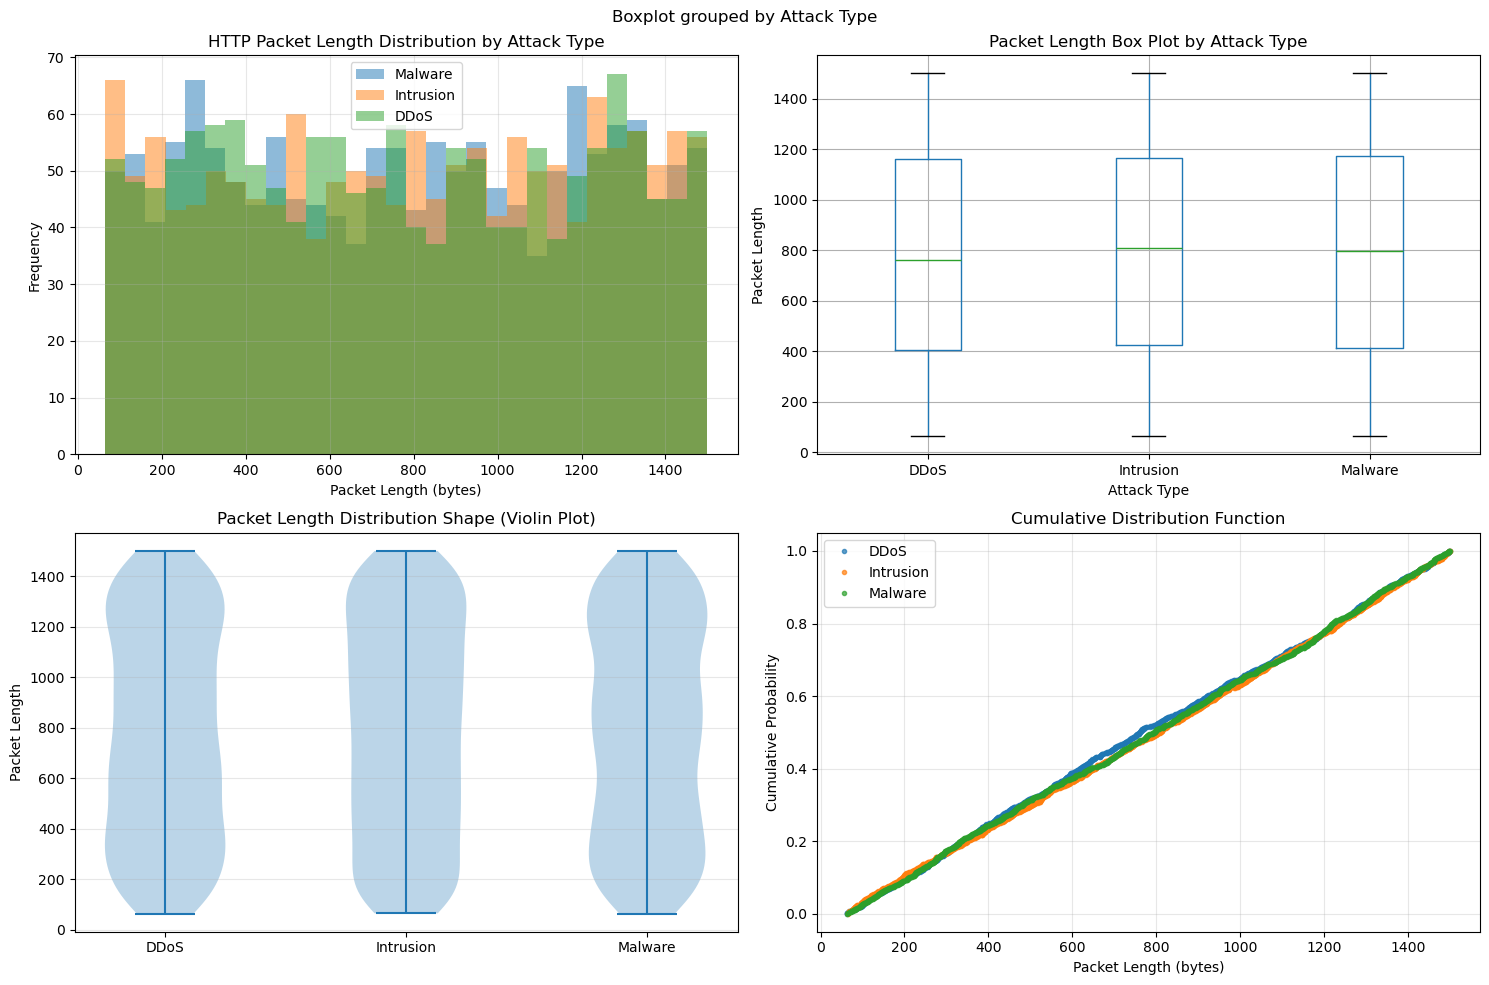


PACKET LENGTH DISTRIBUTION ANALYSIS - HTTP-ICMP TRAFFIC

DDOS
----------------------------------------------------------------------
Count:        1504
Mean:         778.73 bytes
Median:       761.00 bytes
Std Dev:      421.38 bytes
Min:          64.00 bytes
Max:          1500.00 bytes
Range:        1436.00 bytes
IQR:          755.50 bytes
Skewness:     0.030 (Fair)
Kurtosis:     -1.251
Coeff. Var:   0.541

INTRUSION
----------------------------------------------------------------------
Count:        1519
Mean:         793.29 bytes
Median:       810.00 bytes
Std Dev:      423.52 bytes
Min:          65.00 bytes
Max:          1500.00 bytes
Range:        1435.00 bytes
IQR:          739.00 bytes
Skewness:     -0.051 (Fair)
Kurtosis:     -1.223
Coeff. Var:   0.534

MALWARE
----------------------------------------------------------------------
Count:        1507
Mean:         787.27 bytes
Median:       795.00 bytes
Std Dev:      420.67 bytes
Min:          64.00 bytes
Max:          1500.00 b

In [38]:
import scipy.stats as stats

# Filter HTTP traffic
filter_http = (df['Traffic Type'] == 'HTTP') & (df['Protocol'] == 'ICMP')
http_data = df.loc[filter_http].copy()

# Create comprehensive distribution visualization with 2D grid
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Histogram with attack type overlay (top-left)
for attack_type in http_data['Attack Type'].unique():
    data = http_data[http_data['Attack Type'] == attack_type]['Packet Length']
    axes[0, 0].hist(data, alpha=0.5, label=attack_type, bins=30)
axes[0, 0].set_title('HTTP Packet Length Distribution by Attack Type')
axes[0, 0].set_xlabel('Packet Length (bytes)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Box plot showing skewness & outliers (top-right)
http_data.boxplot(column='Packet Length', by='Attack Type', ax=axes[0, 1])
axes[0, 1].set_title('Packet Length Box Plot by Attack Type')
axes[0, 1].set_xlabel('Attack Type')
axes[0, 1].set_ylabel('Packet Length')

# 3. Violin plot showing distribution shape (bottom-left)
attack_types = sorted(http_data['Attack Type'].unique())
data_by_attack = [http_data[http_data['Attack Type'] == atk]['Packet Length'].values 
                  for atk in attack_types]
axes[1, 0].violinplot(data_by_attack, positions=range(len(attack_types)))
axes[1, 0].set_xticks(range(len(attack_types)))
axes[1, 0].set_xticklabels(attack_types)
axes[1, 0].set_title('Packet Length Distribution Shape (Violin Plot)')
axes[1, 0].set_ylabel('Packet Length')
axes[1, 0].grid(alpha=0.3, axis='y')

# 4. Cumulative Distribution Function (bottom-right)
for attack_type in attack_types:
    data = http_data[http_data['Attack Type'] == attack_type]['Packet Length'].sort_values()
    axes[1, 1].plot(data.values, np.arange(1, len(data) + 1) / len(data), 
                   marker='.', linestyle='none', label=attack_type, alpha=0.7)
axes[1, 1].set_title('Cumulative Distribution Function')
axes[1, 1].set_xlabel('Packet Length (bytes)')
axes[1, 1].set_ylabel('Cumulative Probability')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical fairness analysis
print("\n" + "=" * 70)
print("PACKET LENGTH DISTRIBUTION ANALYSIS - HTTP-ICMP TRAFFIC")
print("=" * 70)

for attack_type in attack_types:
    data = http_data[http_data['Attack Type'] == attack_type]['Packet Length']
    
    print(f"\n{attack_type.upper()}")
    print("-" * 70)
    print(f"Count:        {len(data)}")
    print(f"Mean:         {data.mean():.2f} bytes")
    print(f"Median:       {data.median():.2f} bytes")
    print(f"Std Dev:      {data.std():.2f} bytes")
    print(f"Min:          {data.min():.2f} bytes")
    print(f"Max:          {data.max():.2f} bytes")
    print(f"Range:        {data.max() - data.min():.2f} bytes")
    print(f"IQR:          {data.quantile(0.75) - data.quantile(0.25):.2f} bytes")
    
    # Skewness (0 = fair, >1 = highly skewed)
    skewness = stats.skew(data)
    fairness = 'Fair' if abs(skewness) < 0.5 else 'Skewed' if abs(skewness) < 1 else 'Highly Skewed'
    print(f"Skewness:     {skewness:.3f} ({fairness})")
    
    # Kurtosis
    kurtosis = stats.kurtosis(data)
    print(f"Kurtosis:     {kurtosis:.3f}")
    
    # Coefficient of Variation
    cv = data.std() / data.mean() if data.mean() != 0 else 0
    print(f"Coeff. Var:   {cv:.3f}")

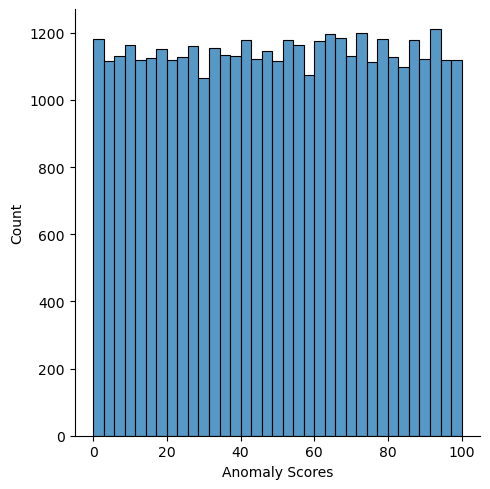

In [239]:
sns.displot(df['Anomaly Scores'])

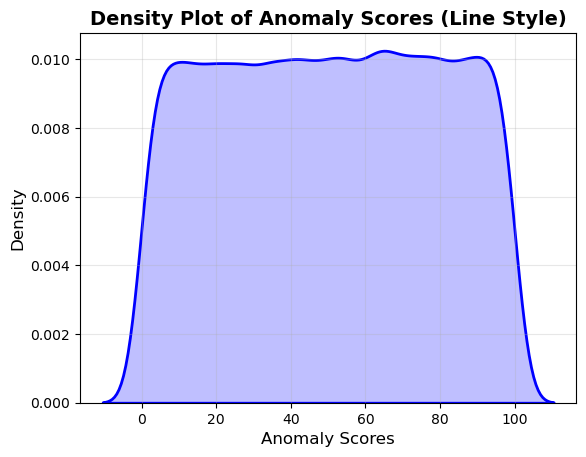

In [255]:
# KDE plot (line plot of density) instead of histogram
sns.kdeplot(df['Anomaly Scores'], fill=True, color='blue', linewidth=2)
plt.title('Density Plot of Anomaly Scores (Line Style)', fontsize=14, fontweight='bold')
plt.xlabel('Anomaly Scores', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

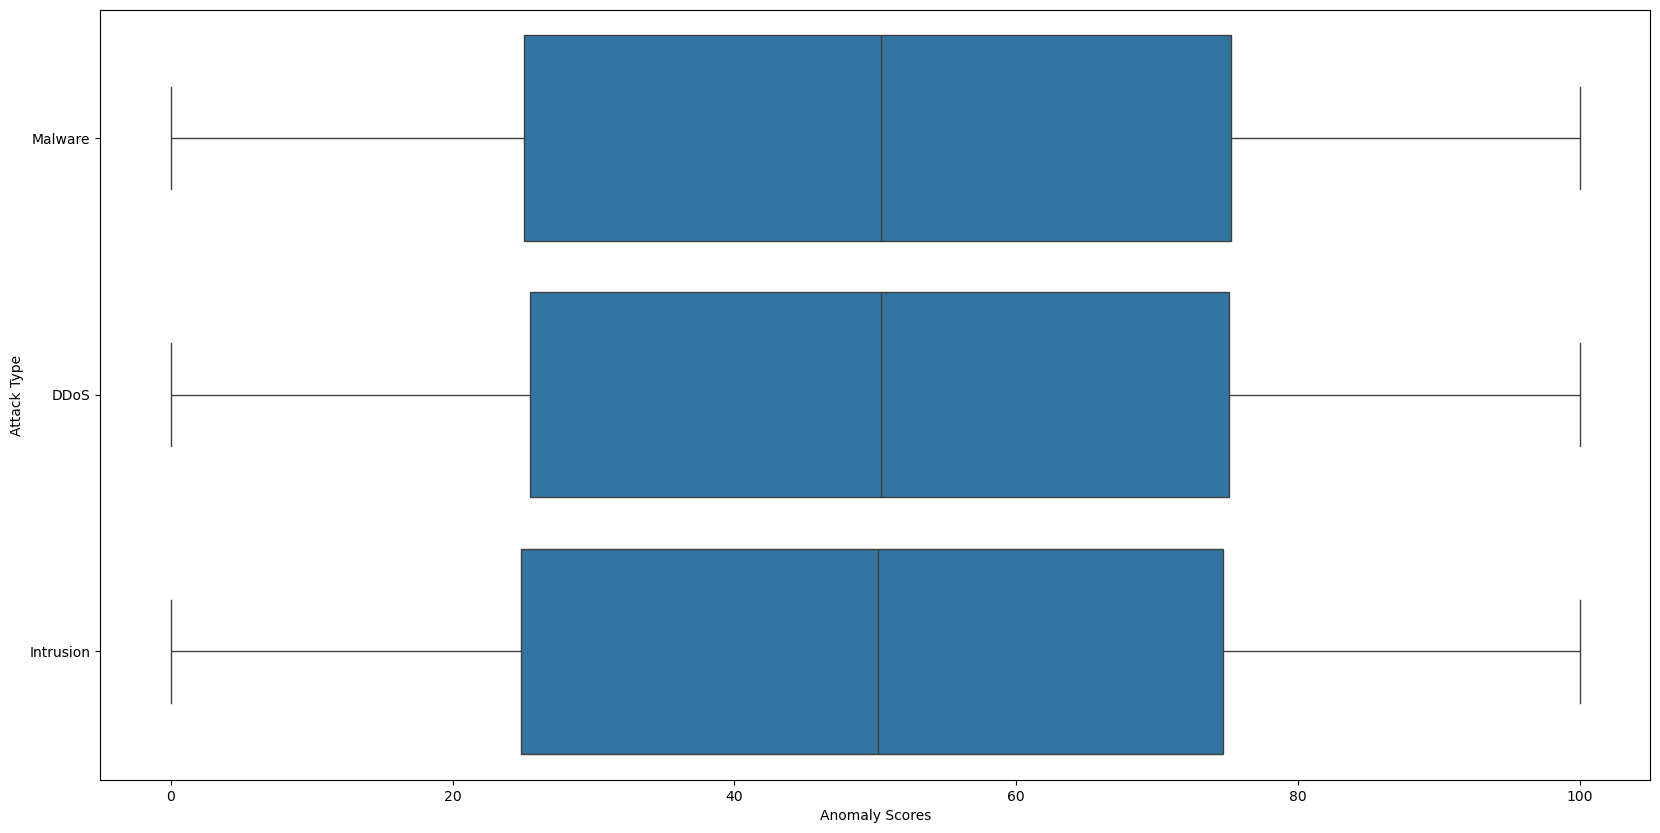

In [ ]:
# Seems like no correlation between Anomaly Scores and Severity Level and with Attack Type
plt.figure(figsize=(20,10))
sns.boxplot(x=df['Anomaly Scores'],y=df['Attack Type'])
plt.show()

In [258]:
ct = df['Anomaly Scores'].describe()
ct

count    40000.000000
mean        50.113473
std         28.853598
min          0.000000
25%         25.150000
50%         50.345000
75%         75.030000
max        100.000000
Name: Anomaly Scores, dtype: float64

In [90]:
# Create packet size categories
def categorize_packet_size(length):
    if length <= 64:
        return 'Tiny'      # Minimal overhead
    elif length < 512:
        return 'Small'     # Control packets
    elif length < 1500:
        return 'Normal'    # Standard MTU
    elif length < 9000:
        return 'Large'     # Jumbo frames
    else:
        return 'Huge'      # Fragmented/Aggregated

# Create single column with categories (no one-hot encoding)
df['pkt_size_category'] = df['Packet Length'].apply(categorize_packet_size)

# Display distribution
print("Packet Size Category Distribution:")
print(df['pkt_size_category'].value_counts().sort_index())
print("\n" + "="*60)

# Quick fairness check: Attack Type vs Packet Size Category
ct = pd.crosstab(df['pkt_size_category'], df['Attack Type'], margins=True)
print("\nAttack Type Distribution by Packet Size Category:")
print(ct)

Packet Size Category Distribution:
pkt_size_category
Large        26
Normal    27452
Small     12489
Tiny         33
Name: count, dtype: int64


Attack Type Distribution by Packet Size Category:
Attack Type         DDoS  Intrusion  Malware    All
pkt_size_category                                  
Large                 13          7        6     26
Normal              9277       9052     9123  27452
Small               4121       4198     4170  12489
Tiny                  17          8        8     33
All                13428      13265    13307  40000


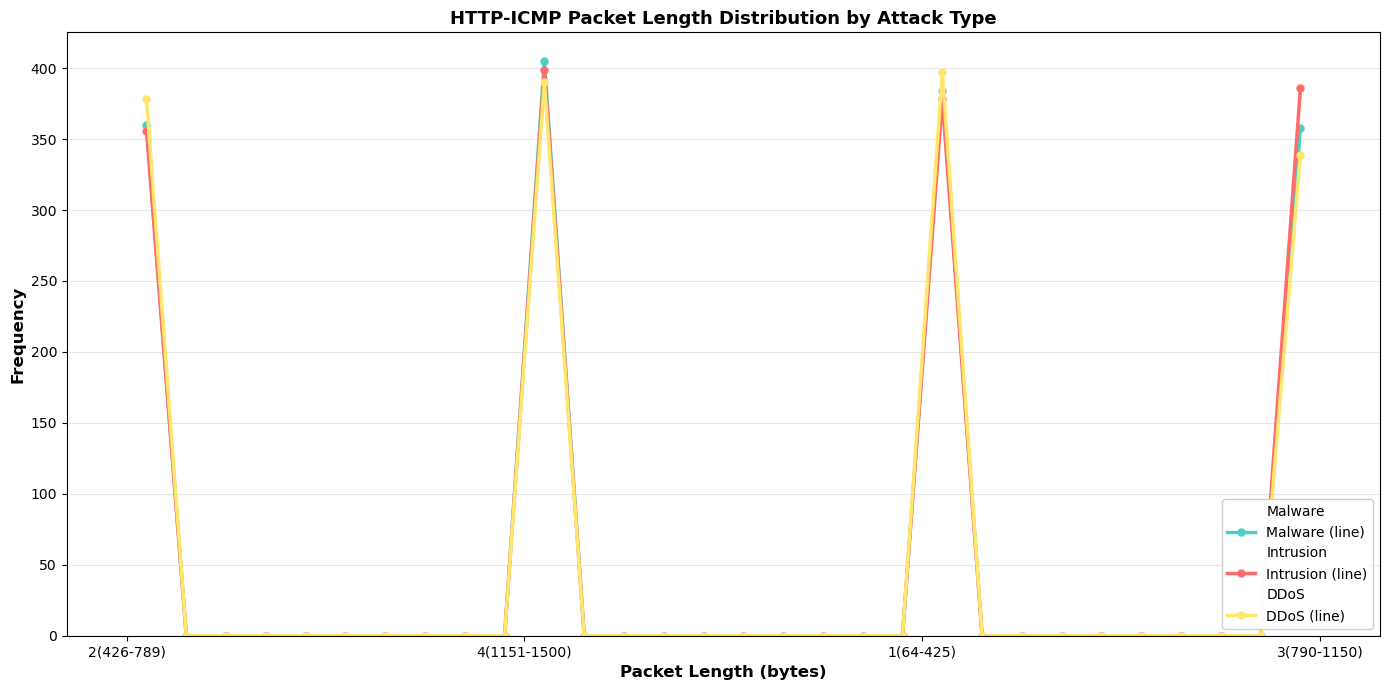

In [ ]:
filter = df['Traffic Type'] == 'FTP' & df['Protocol'] == 'ICMP'
# filter = (df['Traffic Type'] == 'HTTP') & (df['Protocol'] == 'ICMP')
ftp_data = df.loc[filter].copy()

# Get unique attack types
attack_types = ftp_data['Attack Type'].unique()

# Define colors for each attack type
colors = {'Intrusion': '#FF6B6B', 'Malware': '#4ECDC4', 'DDoS': '#FFE66D'}

# Create single plot with all attack types
fig, ax = plt.subplots(figsize=(14, 7))

# Plot each attack type with line overlay only
for attack in attack_types:
    data = ftp_data.loc[ftp_data['Attack Type'] == attack, 'Packet_Length_Quartile']
    
    # Create histogram to get counts and bins
    counts, bins, patches = ax.hist(data, bins=30, alpha=0.0, 
                                     label=f'{attack}', 
                                     color=colors.get(attack, 'blue'))
    
    # Line plot overlay connecting histogram centers
    bin_centers = (bins[:-1] + bins[1:]) / 2
    ax.plot(bin_centers, counts, color=colors.get(attack, 'blue'), 
            linewidth=2.5, marker='o', markersize=5, 
            label=f'{attack} (line)')

ax.set_xlabel('Packet Length (bytes)', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax.set_title('FTP-ICMP Packet Length Distribution by Attack Type', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.legend(loc='lower right', framealpha=0.95)
plt.tight_layout()
plt.show()

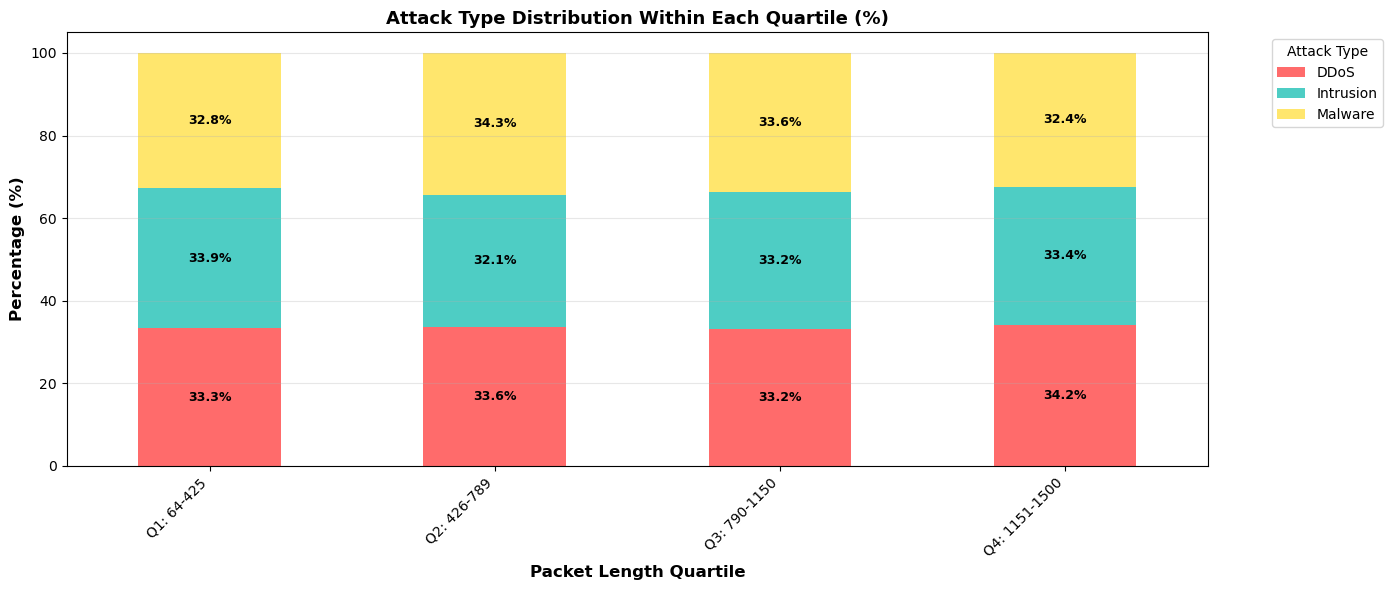


✓ Shows FAIRNESS: Are attack types equally distributed in each quartile?
✓ If percentages are similar across quartiles → Fair
✓ If one attack type dominates a quartile → Unfair/Biased

PERCENTAGE TABLE:
Attack Type              DDoS  Intrusion  Malware
Packet_Length_Quartile                           
Q1: 64-425              33.27      33.94    32.79
Q2: 426-789             33.58      32.10    34.32
Q3: 790-1150            33.22      33.21    33.56
Q4: 1151-1500           34.23      33.39    32.38


In [60]:
# OPTION 2: Stacked percentage bar (fairness view) WITH PERCENTAGES
fig, ax = plt.subplots(figsize=(14, 6))

# Create quartile column if not exists
df['Packet_Length_Quartile'] = pd.cut(
    df['Packet Length'],
    bins=[64, 425, 789, 1150, 1500],
    labels=['Q1: 64-425', 'Q2: 426-789', 'Q3: 790-1150', 'Q4: 1151-1500'],
    include_lowest=True
)

# Create crosstab: rows=quartiles, columns=attack types, values=counts
ct = pd.crosstab(df['Packet_Length_Quartile'], df['Attack Type'], normalize='index') * 100

# Stacked bar
ct.plot(kind='bar', stacked=True, ax=ax, color=['#FF6B6B', '#4ECDC4', '#FFE66D'])

# ============================================================
# ADD PERCENTAGE LABELS ON BARS
# ============================================================
for container in ax.containers:
    labels = [f'{v:.1f}%' if v > 3 else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=9, fontweight='bold')

ax.set_title('Attack Type Distribution Within Each Quartile (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Packet Length Quartile', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax.legend(title='Attack Type', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n✓ Shows FAIRNESS: Are attack types equally distributed in each quartile?")
print("✓ If percentages are similar across quartiles → Fair")
print("✓ If one attack type dominates a quartile → Unfair/Biased")

# Print percentage table for reference
print("\n" + "="*80)
print("PERCENTAGE TABLE:")
print("="*80)
print(ct.round(2))

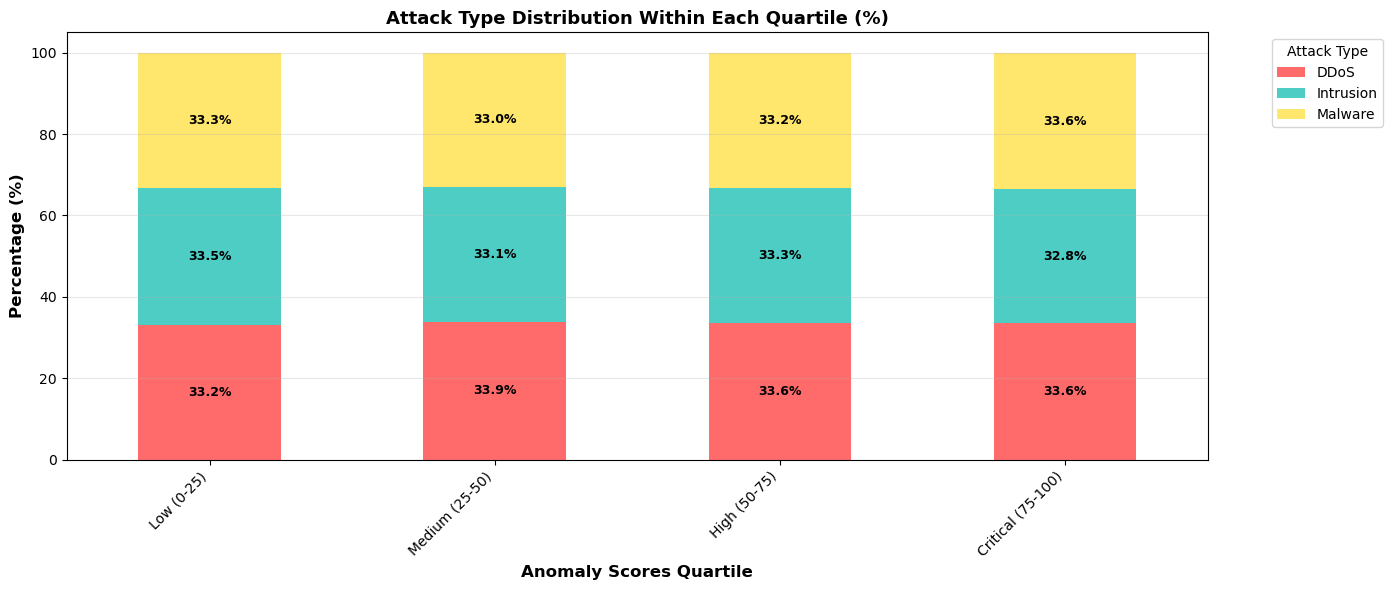


✓ Shows FAIRNESS: Are attack types equally distributed in each quartile?
✓ If percentages are similar across quartiles → Fair
✓ If one attack type dominates a quartile → Unfair/Biased

PERCENTAGE TABLE:
Attack Type               DDoS  Intrusion  Malware
Anomaly Scores_Quartile                           
Low (0-25)               33.19      33.49    33.33
Medium (25-50)           33.91      33.08    33.01
High (50-75)             33.58      33.26    33.16
Critical (75-100)        33.60      32.80    33.59


In [ ]:
# feature engineering for Anomaly Scores by Quartile
fig, ax = plt.subplots(figsize=(14, 6))

# Create quartile column if not exists
df['Anomaly Scores_Quartile'] = pd.cut(
    df['Anomaly Scores'],
    bins=[0, 25, 50, 75, 100],
    labels=['Low (0-25)', 'Medium (25-50)', 'High (50-75)', 'Critical (75-100)']
)

# Create crosstab: rows=quartiles, columns=attack types, values=counts
ct = pd.crosstab(df['Anomaly Scores_Quartile'], df['Attack Type'], normalize='index') * 100
# Stacked bar
ct.plot(kind='bar', stacked=True, ax=ax, color=['#FF6B6B', '#4ECDC4', '#FFE66D'])

# ============================================================
# ADD PERCENTAGE LABELS ON BARS
# ============================================================
for container in ax.containers:
    labels = [f'{v:.1f}%' if v > 3 else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=9, fontweight='bold')

ax.set_title('Attack Type Distribution Within Each Quartile (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Anomaly Scores Quartile', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax.legend(title='Attack Type', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n✓ Shows FAIRNESS: Are attack types equally distributed in each quartile?")
print("✓ If percentages are similar across quartiles → Fair")
print("✓ If one attack type dominates a quartile → Unfair/Biased")

# Print percentage table for reference
print("\n" + "="*80)
print("PERCENTAGE TABLE:")
print("="*80)
print(ct.round(2))

In [264]:
df

,Timestamp,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Malware Indicators,Anomaly Scores,Alerts/Warnings,...,Destination Port_Cat,Year,Month,Day,Hours_div,GeoLoc_Country,GeoLoc_Country1,Packet_Length_Quartile,Day_Number,Is_Weekend
0,2023-05-30 06:33:58,31225,17616,ICMP,503,Data,HTTP,1,Q2: 26-50,0,...,Registered,2023,5,30,2,India,India,Q2: 426-789,1,Weekday
1,2020-08-26 07:08:30,17245,48166,ICMP,1174,Data,HTTP,1,Q3: 51-75,0,...,Registered,2020,8,26,2,India,India,Q4: 1151-1500,2,Weekday
2,2022-11-13 08:23:25,16811,53600,UDP,306,Control,HTTP,1,Q4: 76-100,1,...,Dynamic,2022,11,13,2,India,India,Q1: 64-425,6,Weekend
3,2023-07-02 10:38:46,20018,32534,UDP,385,Data,HTTP,0,Q1: 0-25,1,...,Registered,2023,7,2,2,India,India,Q1: 64-425,6,Weekend
4,2023-07-16 13:11:07,6131,26646,TCP,1462,Data,DNS,0,Q1: 0-25,1,...,Registered,2023,7,16,3,India,India,Q4: 1151-1500,6,Weekend
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,2023-05-26 14:08:42,31005,6764,UDP,1428,Control,HTTP,1,Q2: 26-50,0,...,Registered,2023,5,26,3,India,India,Q4: 1151-1500,4,Weekday
39996,2023-03-27 00:38:27,2553,28091,UDP,1184,Control,HTTP,1,Q2: 26-50,0,...,Registered,2023,3,27,1,India,India,Q4: 1151-1500,0,Weekday
39997,2022-03-31 01:45:49,22505,25152,UDP,1043,Data,DNS,1,Q2: 26-50,0,...,Registered,2022,3,31,1,India,India,Q3: 790-1150,3,Weekday
39998,2023-09-22 18:32:38,20013,2703,UDP,483,Data,FTP,1,Q4: 76-100,1,...,Registered,2023,9,22,4,India,India,Q2: 426-789,4,Weekday


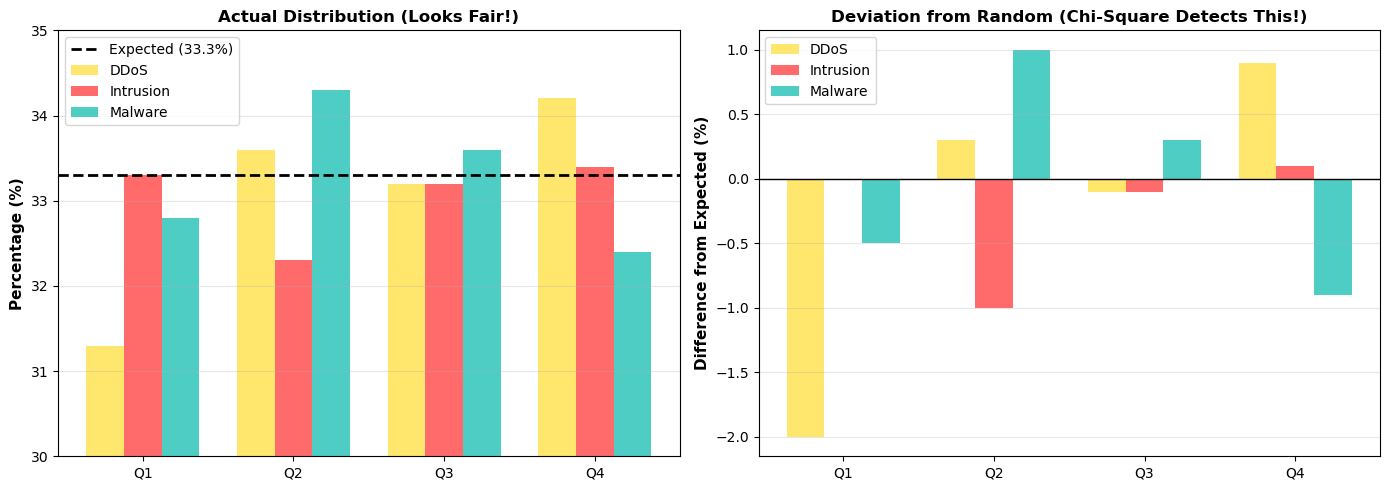

The RIGHT plot shows why chi-square found significance:
- Small but CONSISTENT deviations
- With n=31,761, these add up!
- Proves: Quartile DOES influence Attack Type


In [61]:
# Let's visualize the ACTUAL differences
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ============================================================
# Left: Your percentages (looks fair)
# ============================================================
quartiles = ['Q1', 'Q2', 'Q3', 'Q4']
ddos = [31.3, 33.6, 33.2, 34.2]
intrusion = [33.3, 32.3, 33.2, 33.4]
malware = [32.8, 34.3, 33.6, 32.4]
expected = [33.3, 33.3, 33.3, 33.3]

x = np.arange(len(quartiles))
width = 0.25

axes[0].bar(x - width, ddos, width, label='DDoS', color='#FFE66D')
axes[0].bar(x, intrusion, width, label='Intrusion', color='#FF6B6B')
axes[0].bar(x + width, malware, width, label='Malware', color='#4ECDC4')
axes[0].axhline(y=33.3, color='black', linestyle='--', linewidth=2, label='Expected (33.3%)')
axes[0].set_ylabel('Percentage (%)', fontsize=11, fontweight='bold')
axes[0].set_title('Actual Distribution (Looks Fair!)', fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(quartiles)
axes[0].legend()
axes[0].set_ylim(30, 35)
axes[0].grid(axis='y', alpha=0.3)

# ============================================================
# Right: The DIFFERENCES from expected (shows bias)
# ============================================================
ddos_diff = np.array(ddos) - 33.3
intrusion_diff = np.array(intrusion) - 33.3
malware_diff = np.array(malware) - 33.3

axes[1].bar(x - width, ddos_diff, width, label='DDoS', color='#FFE66D')
axes[1].bar(x, intrusion_diff, width, label='Intrusion', color='#FF6B6B')
axes[1].bar(x + width, malware_diff, width, label='Malware', color='#4ECDC4')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[1].set_ylabel('Difference from Expected (%)', fontsize=11, fontweight='bold')
axes[1].set_title('Deviation from Random (Chi-Square Detects This!)', fontsize=12, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(quartiles)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("The RIGHT plot shows why chi-square found significance:")
print("- Small but CONSISTENT deviations")
print("- With n=31,761, these add up!")
print("- Proves: Quartile DOES influence Attack Type")

In [84]:
# Chi-square test
# feature engineering of Packet Length by Packet_Length_Quartile - OK
from scipy.stats import chi2_contingency

# Chi-square test: Does attack type distribution differ by quartile?
ct = pd.crosstab(df['Packet_Length_Quartile'], df['Attack Type'])
chi2, p_val, dof, expected = chi2_contingency(ct)

print(f"Chi-Square Test for Independence:")
print(f"χ² = {chi2:.4f}")
print(f"p-value = {p_val:.6f}")
print(f"\nInterpretation:")
if p_val > 0.05:
    print("✓ Attack types ARE fairly distributed across quartiles (p > 0.05)")
else:
    print("✗ Attack types are NOT fairly distributed (p < 0.05) - Biased quartiles!")

Chi-Square Test for Independence:
χ² = 13.9522
p-value = 0.030174

Interpretation:
✗ Attack types are NOT fairly distributed (p < 0.05) - Biased quartiles!


In [268]:
# Chi-square test
# feature engineering of Packet Length by Anomaly Scores_Quartile - OK
from scipy.stats import chi2_contingency

# Chi-square test: Does attack type distribution differ by quartile?
ct = pd.crosstab(df['Anomaly Scores_Quartile'], df['Attack Type'])
chi2, p_val, dof, expected = chi2_contingency(ct)

print(f"Chi-Square Test for Independence:")
print(f"χ² = {chi2:.4f}")
print(f"p-value = {p_val:.6f}")
print(f"\nInterpretation:")
if p_val > 0.05:
    print("✓ Attack types ARE fairly distributed across quartiles (p > 0.05)")
else:
    print("✗ Attack types are NOT fairly distributed (p < 0.05) - Biased quartiles!")

Chi-Square Test for Independence:
χ² = 2.1192
p-value = 0.908420

Interpretation:
✓ Attack types ARE fairly distributed across quartiles (p > 0.05)


In [ ]:
# Chi-square test
# feature engineering of Packet Length by pkt_size_category - NOK
    # if length <= 64:
    #     return 'Tiny'      # Minimal overhead
    # elif length < 512:
    #     return 'Small'     # Control packets
    # elif length < 1500:
    #     return 'Normal'    # Standard MTU
    # elif length < 9000:
    #     return 'Large'     # Jumbo frames
    # else:
    #     return 'Huge'      # Fragmented/Aggregated
from scipy.stats import chi2_contingency

# Chi-square test: Does attack type distribution differ by quartile?
ct = pd.crosstab(df['pkt_size_category'], df['Attack Type'])
chi2, p_val, dof, expected = chi2_contingency(ct)

print(f"Chi-Square Test for Independence:")
print(f"χ² = {chi2:.4f}")
print(f"p-value = {p_val:.6f}")
print(f"\nInterpretation:")
if p_val > 0.05:
    print("✓ Attack types ARE fairly distributed across quartiles (p > 0.05)")
else:
    print("✗ Attack types are NOT fairly distributed (p < 0.05) - Biased quartiles!")

Chi-Square Test for Independence:
χ² = 10.7294
p-value = 0.097110

Interpretation:
✓ Attack types ARE fairly distributed across quartiles (p > 0.05)


In [ ]:
# Chi-square test
# feature engineering of Packet Length by Packet_Length_Quantile - NOK
# ['Q1 (20%)' < 'Q2 (40%)' < 'Q3 (60%)' < 'Q4 (80%)' < 'Q5 (100%)']
from scipy.stats import chi2_contingency

# Chi-square test: Does attack type distribution differ by quartile?
ct = pd.crosstab(df['Packet_Length_Quantile'], df['Attack Type'])
chi2, p_val, dof, expected = chi2_contingency(ct)

print(f"Chi-Square Test for Independence:")
print(f"χ² = {chi2:.4f}")
print(f"p-value = {p_val:.6f}")
print(f"\nInterpretation:")
if p_val > 0.05:
    print("✓ Attack types ARE fairly distributed across quartiles (p > 0.05)")
else:
    print("✗ Attack types are NOT fairly distributed (p < 0.05) - Biased quartiles!")

Chi-Square Test for Independence:
χ² = 12.7371
p-value = 0.121221

Interpretation:
✓ Attack types ARE fairly distributed across quartiles (p > 0.05)


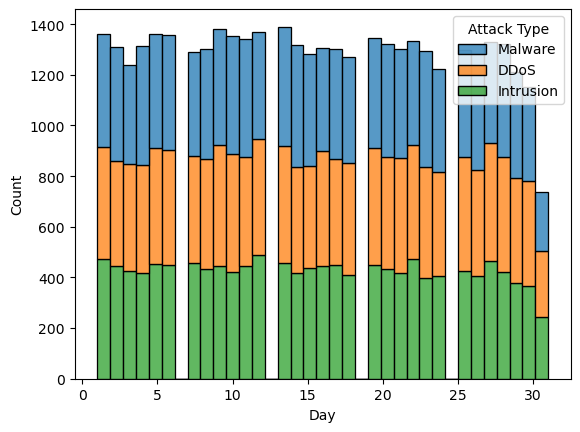

In [100]:
sns.histplot(x="Day",hue="Attack Type",multiple="stack",data=df)
plt.show()

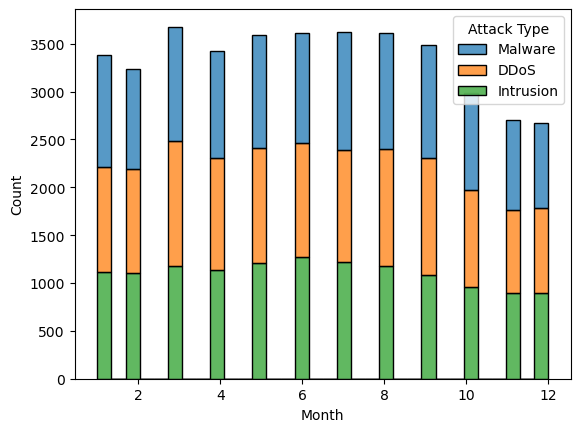

In [279]:
sns.histplot(x="Month",hue="Attack Type",multiple="stack",data=df)
plt.show()

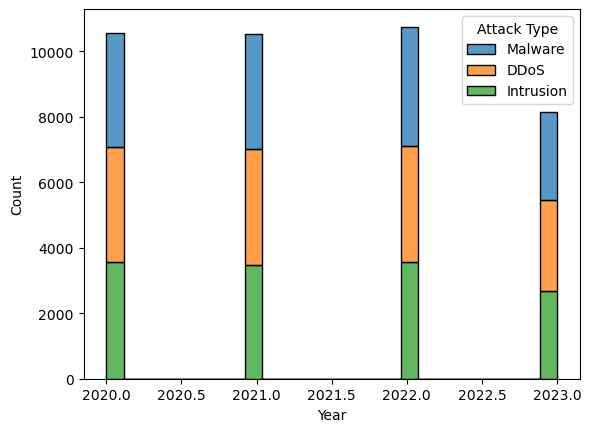

In [281]:
sns.histplot(x="Year",hue="Attack Type",multiple="stack",data=df)
plt.show()

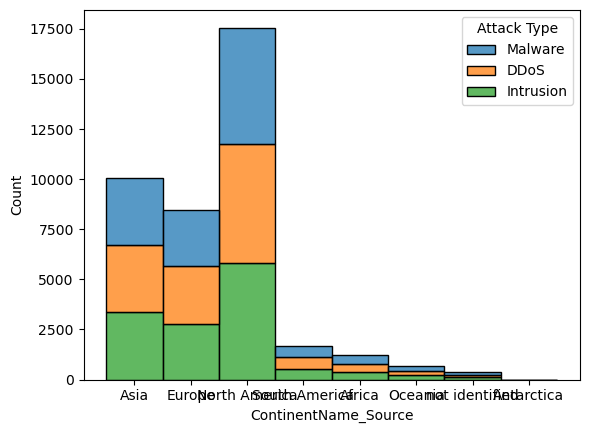

In [286]:
sns.histplot(x='ContinentName_Source',hue="Attack Type",multiple="stack",data=df)
plt.show()

In [291]:
df.groupby('ContinentName_Source')['Attack Type'].value_counts()


ContinentName_Source  Attack Type
Africa                Malware         414
                      DDoS            409
                      Intrusion       389
Antarctica            Malware           1
Asia                  Intrusion      3375
                      DDoS           3337
                      Malware        3333
Europe                DDoS           2863
                      Malware        2819
                      Intrusion      2790
North America         DDoS           5922
                      Intrusion      5838
                      Malware        5802
Oceania               Malware         240
                      Intrusion       211
                      DDoS            210
South America         Malware         574
                      DDoS            567
                      Intrusion       549
not identified        Malware         124
                      DDoS            120
                      Intrusion       113
Name: count, dtype: int64

In [ ]:
# 25304 missing values - almost 65%
df['OS_minor'].value_counts()

OS_minor
not specified    25304
1                 2328
3                 2216
2                 2164
0                 1534
6                  818
5                  790
9                  755
11                 739
10                 727
12                 725
7                  704
8                  671
4                  525
Name: count, dtype: int64

In [ ]:
# 29318 missing values - almost 75%
df['OS_patch'].value_counts()

OS_patch
not specified    29318
1                 2085
3                 1426
2                 1284
6                 1227
4                 1032
5                  928
8                  829
0                  662
7                  630
9                  579
Name: count, dtype: int64

In [292]:
# drop OS_patch and OS_minor - too many missing values (65% and 75%)
# Risk to bias model towards "not specified" (missing value) category
# To consider: Bin version???
df_for_stats.drop(columns=['OS_minor', 'OS_patch'], inplace=True)

In [293]:
ct = pd.crosstab(df['ContinentName_Source'], df['Attack Type'])
ct

Attack Type,DDoS,Intrusion,Malware
ContinentName_Source,,,
Africa,409,389,414
Antarctica,0,0,1
Asia,3337,3375,3333
Europe,2863,2790,2819
North America,5922,5838,5802
Oceania,210,211,240
South America,567,549,574
not identified,120,113,124


In [294]:
ct = pd.crosstab(df['ContinentName_Source'], df['Attack Type'], normalize='index') * 100
ct.round(2)

Attack Type,DDoS,Intrusion,Malware
ContinentName_Source,,,
Africa,33.75,32.10,34.16
Antarctica,0.00,0.00,100.00
Asia,33.22,33.60,33.18
Europe,33.79,32.93,33.27
North America,33.72,33.24,33.04
Oceania,31.77,31.92,36.31
South America,33.55,32.49,33.96
not identified,33.61,31.65,34.73


In [296]:
ct = pd.crosstab(df['ContinentName_Destination'], df['Attack Type'])
ct

Attack Type,DDoS,Intrusion,Malware
ContinentName_Destination,,,
Africa,399,402,393
Asia,3481,3343,3378
Europe,2855,2792,2810
North America,5798,5876,5864
Oceania,226,198,192
South America,543,545,567
not identified,126,109,103


In [295]:
ct = pd.crosstab(df['ContinentName_Destination'], df['Attack Type'], normalize='index') * 100
ct.round(2)

Attack Type,DDoS,Intrusion,Malware
ContinentName_Destination,,,
Africa,33.42,33.67,32.91
Asia,34.12,32.77,33.11
Europe,33.76,33.01,33.23
North America,33.06,33.50,33.44
Oceania,36.69,32.14,31.17
South America,32.81,32.93,34.26
not identified,37.28,32.25,30.47


In [298]:
ct = pd.crosstab(df['ContinentName_Proxy'], df['Attack Type'])
ct

Attack Type,DDoS,Intrusion,Malware
ContinentName_Proxy,,,
Africa,202,193,214
Asia,1743,1696,1793
Europe,1420,1383,1439
North America,2977,2875,2900
Oceania,105,116,108
South America,277,273,269
noProxy,6643,6668,6540
not identified,61,61,44


In [299]:
ct = pd.crosstab(df['ContinentName_Proxy'], df['Attack Type'], normalize='index') * 100
ct.round(2)

Attack Type,DDoS,Intrusion,Malware
ContinentName_Proxy,,,
Africa,33.17,31.69,35.14
Asia,33.31,32.42,34.27
Europe,33.47,32.60,33.92
North America,34.02,32.85,33.14
Oceania,31.91,35.26,32.83
South America,33.82,33.33,32.84
noProxy,33.46,33.59,32.95
not identified,36.75,36.75,26.51


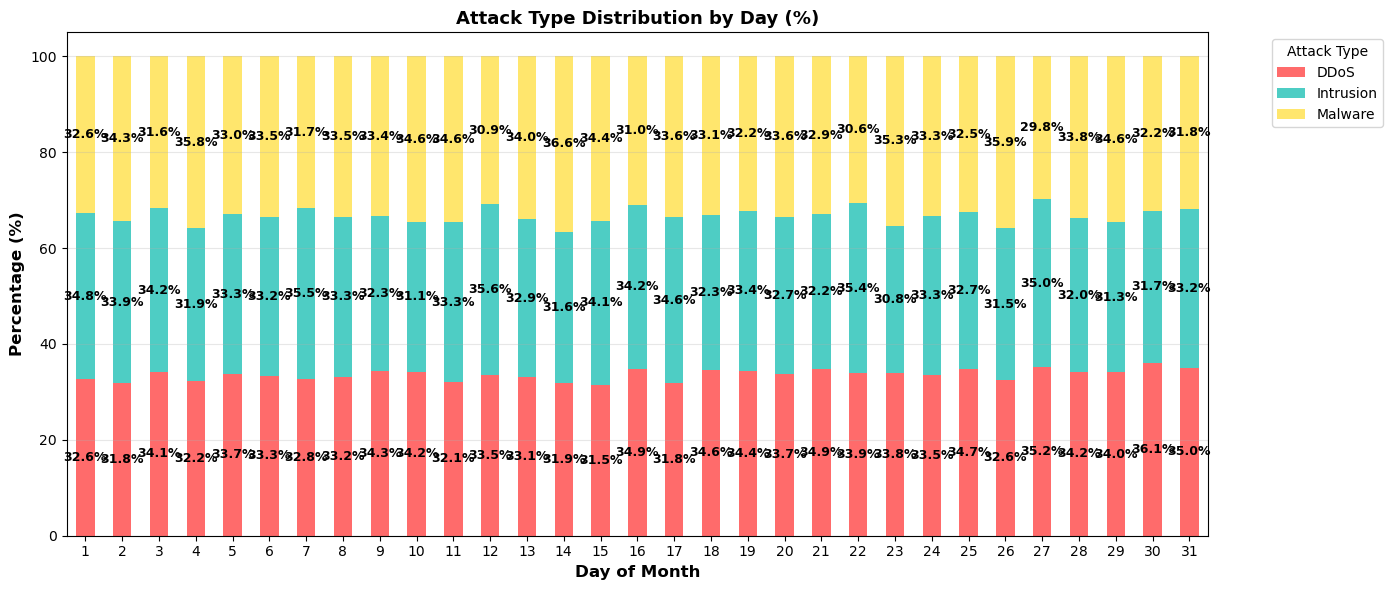

Day vs Attack Type Distribution (%):
Attack Type   DDoS  Intrusion  Malware
Day                                   
1            32.62      34.75    32.62
2            31.78      33.92    34.30
3            34.14      34.22    31.64
4            32.24      31.94    35.82
5            33.70      33.33    32.97
6            33.28      33.21    33.51
7            32.79      35.50    31.71
8            33.18      33.33    33.49
9            34.30      32.34    33.36
10           34.24      31.14    34.61
11           32.09      33.28    34.63
12           33.46      35.65    30.90
13           33.09      32.95    33.96
14           31.87      31.56    36.57
15           31.51      34.09    34.40
16           34.87      34.18    30.96
17           31.83      34.59    33.59
18           34.59      32.31    33.10
19           34.37      33.41    32.22
20           33.71      32.73    33.56
21           34.87      32.18    32.95
22           33.93      35.44    30.63
23           33.85      30.

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the stacked histogram
fig, ax = plt.subplots(figsize=(14, 6))

# Create crosstab for Day vs Attack Type
ct = pd.crosstab(df['Day'], df['Attack Type'], normalize='index') * 100

# Plot as stacked bar
ct.plot(kind='bar', stacked=True, ax=ax, 
        color=['#FF6B6B', '#4ECDC4', '#FFE66D'])

# Add percentage labels on each segment
for container in ax.containers:
    labels = [f'{v:.1f}%' if v > 2 else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='center', 
                fontsize=9, fontweight='bold')

ax.set_title('Attack Type Distribution by Day (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Day of Month', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax.legend(title='Attack Type', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Day vs Attack Type Distribution (%):")
print(ct.round(2))

In [103]:
# Convert Timestamps column to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Method 1: Get day of week name (Monday, Tuesday, etc.)
df['Day_Name'] = df['Timestamp'].dt.day_name()

# Method 2: Get day of week number (0=Monday, 6=Sunday)
df['Day_Number'] = df['Timestamp'].dt.dayofweek

# Method 3: Create Weekday/Weekend column
df['Is_Weekend'] = df['Timestamp'].dt.dayofweek.isin([5, 6]).map({True: 'Weekend', False: 'Weekday'})

# View results
print(df[['Timestamp', 'Day_Name', 'Day_Number', 'Is_Weekend']].head(10))

            Timestamp   Day_Name  Day_Number Is_Weekend
0 2023-05-30 06:33:58    Tuesday           1    Weekday
1 2020-08-26 07:08:30  Wednesday           2    Weekday
2 2022-11-13 08:23:25     Sunday           6    Weekend
3 2023-07-02 10:38:46     Sunday           6    Weekend
4 2023-07-16 13:11:07     Sunday           6    Weekend
5 2022-10-28 13:14:27     Friday           4    Weekday
6 2022-05-16 17:55:43     Monday           0    Weekday
7 2023-02-12 07:13:17     Sunday           6    Weekend
8 2023-06-27 11:02:56    Tuesday           1    Weekday
9 2021-08-15 22:29:04     Sunday           6    Weekend


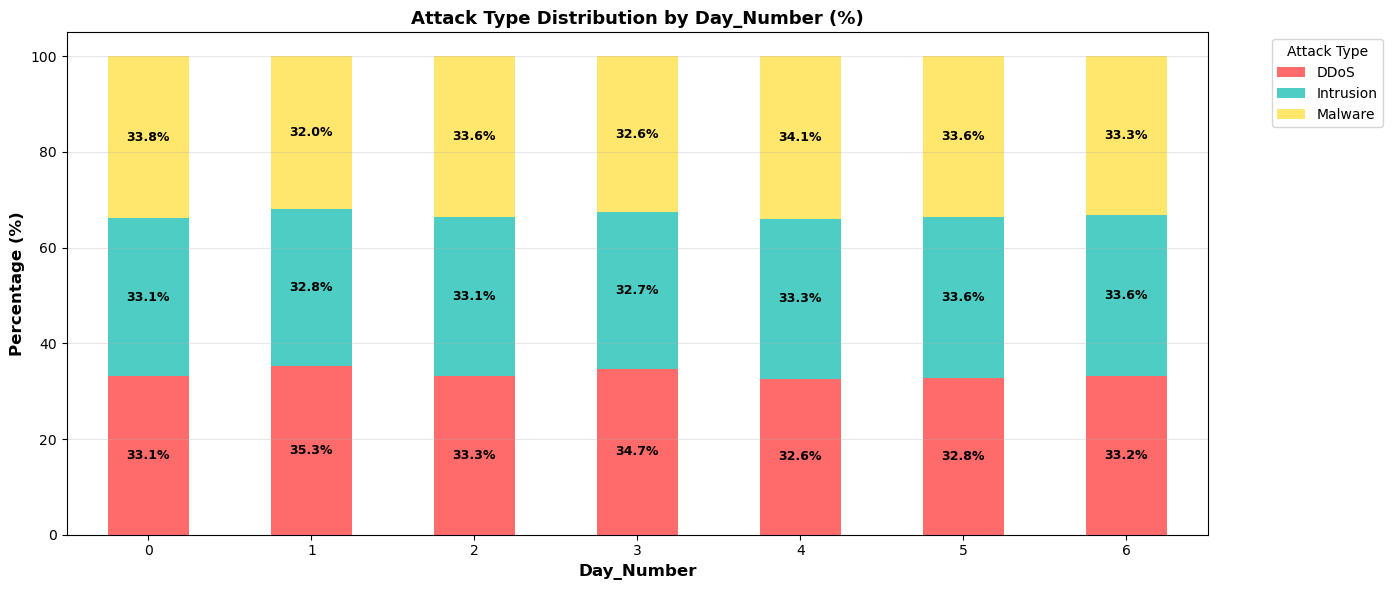

Day_Number vs Attack Type Distribution (%):
Attack Type   DDoS  Intrusion  Malware
Day_Number                            
0            33.14      33.07    33.80
1            35.27      32.75    31.98
2            33.27      33.15    33.58
3            34.71      32.73    32.56
4            32.63      33.29    34.09
5            32.79      33.59    33.62
6            33.17      33.57    33.27


In [134]:
# Create the stacked histogram
fig, ax = plt.subplots(figsize=(14, 6))

# Create crosstab for Day vs Attack Type
ct = pd.crosstab(df['Day_Number'], df['Attack Type'], normalize='index') * 100

# Plot as stacked bar
ct.plot(kind='bar', stacked=True, ax=ax, 
        color=['#FF6B6B', '#4ECDC4', '#FFE66D'])

# Add percentage labels on each segment
for container in ax.containers:
    labels = [f'{v:.1f}%' if v > 2 else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='center', 
                fontsize=9, fontweight='bold')

ax.set_title('Attack Type Distribution by Day_Number (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Day_Number', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax.legend(title='Attack Type', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Day_Number vs Attack Type Distribution (%):")
print(ct.round(2))

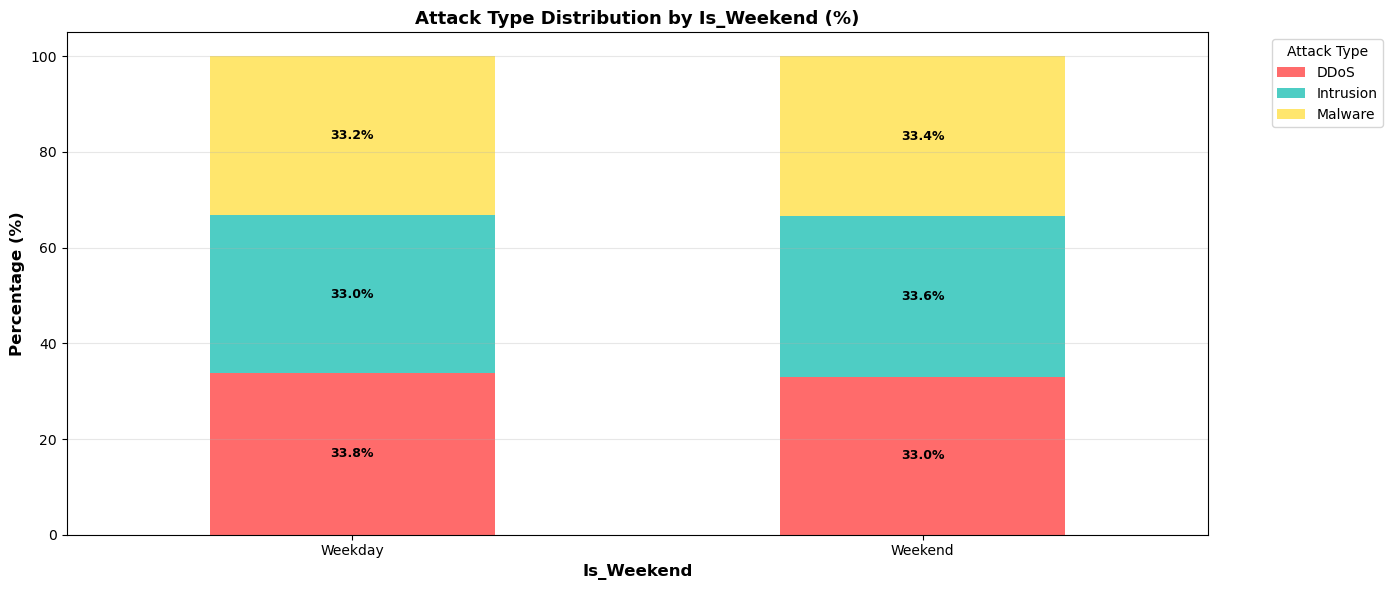

Is_Weekend vs Attack Type Distribution (%):
Attack Type   DDoS  Intrusion  Malware
Is_Weekend                            
Weekday      33.81      33.00    33.20
Weekend      32.98      33.58    33.44


In [105]:
# Create the stacked histogram
fig, ax = plt.subplots(figsize=(14, 6))

# Create crosstab for Day vs Attack Type
ct = pd.crosstab(df['Is_Weekend'], df['Attack Type'], normalize='index') * 100

# Plot as stacked bar
ct.plot(kind='bar', stacked=True, ax=ax, 
        color=['#FF6B6B', '#4ECDC4', '#FFE66D'])

# Add percentage labels on each segment
for container in ax.containers:
    labels = [f'{v:.1f}%' if v > 2 else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='center', 
                fontsize=9, fontweight='bold')

ax.set_title('Attack Type Distribution by Is_Weekend (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Is_Weekend', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax.legend(title='Attack Type', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Is_Weekend vs Attack Type Distribution (%):")
print(ct.round(2))

In [122]:
# Chi-square test for Is_Weekend, Day_Name, Day, Month, Year, Hours_div - fairly distributed
# Is_Weekend
from scipy.stats import chi2_contingency

# Chi-square test: Does attack type distribution differ by quartile?
ct = pd.crosstab(df['Hours_div'], df['Attack Type'])
chi2, p_val, dof, expected = chi2_contingency(ct)

print(f"Chi-Square Test for Independence:")
print(f"χ² = {chi2:.4f}")
print(f"p-value = {p_val:.6f}")
print(f"\nInterpretation:")
if p_val > 0.05:
    print("✓ Attack types ARE fairly distributed across quartiles (p > 0.05)")
else:
    print("✗ Attack types are NOT fairly distributed (p < 0.05) - Biased quartiles!")

Chi-Square Test for Independence:
χ² = 2.0247
p-value = 0.917410

Interpretation:
✓ Attack types ARE fairly distributed across quartiles (p > 0.05)


In [ ]:
# Chi-square test for Is_Weekend, Day_Name, Day, Month, Year, Hours_div - fairly distributed
# between all features above, Day_Name has more considerable p-value at 0.13, the rest is over 0.2
ct = pd.crosstab(df['Day_Name'], df['Attack Type'])
chi2, p_val, dof, expected = chi2_contingency(ct)

print(f"Chi-Square Test for Independence:")
print(f"χ² = {chi2:.4f}")
print(f"p-value = {p_val:.6f}")
print(f"\nInterpretation:")

if p_val > 0.05:
    print("\n✓ FAIR DISTRIBUTION (p > 0.05):")
    print("  → Attack types appear EQUALLY across all time periods")
    print("  → Day_Name is WEAKLY predictive of Attack Type")
    print("  → Decision: KEEP but expect low feature importance")
    print("  → Potential: Combine with other features")
else:
    print("\n✗ BIASED DISTRIBUTION (p < 0.05):")
    print("  → Attack types appear MORE in certain time periods")
    print("  → Day_Name is STRONGLY predictive of Attack Type")
    print("  → Decision: DEFINITELY KEEP - valuable feature!")

Chi-Square Test for Independence:
χ² = 17.4762
p-value = 0.132547

Interpretation:

✓ FAIR DISTRIBUTION (p > 0.05):
  → Attack types appear EQUALLY across all time periods
  → Day_Name is WEAKLY predictive of Attack Type
  → Decision: KEEP but expect low feature importance
  → Potential: Combine with other features


In [ ]:
# Chi-square test
# feature engineering of Packet Length by dividing in Packet_Length_Bin - NOT OK
# 'Tiny (0-250)' < 'Small (251-500)' < 'Medium (501-750)' < 'Large (751-1000)' < 'XLarge (1001-1200)' < 'Jumbo (1200+)
from scipy.stats import chi2_contingency

# Chi-square test: Does attack type distribution differ by quartile?
ct = pd.crosstab(df['Packet_Length_Bin'], df['Attack Type'])
chi2, p_val, dof, expected = chi2_contingency(ct)

print(f"Chi-Square Test for Independence:")
print(f"χ² = {chi2:.4f}")
print(f"p-value = {p_val:.6f}")
print(f"\nInterpretation:")
if p_val > 0.05:
    print("✓ Attack types ARE fairly distributed across quartiles (p > 0.05)")
else:
    print("✗ Attack types are NOT fairly distributed (p < 0.05) - Biased quartiles!")

Chi-Square Test for Independence:
χ² = 11.1645
p-value = 0.344844

Interpretation:
✓ Attack types ARE fairly distributed across quartiles (p > 0.05)


In [ ]:
# Chi-square test
# feature engineering of Packet Length by dividing in quartile bins
from scipy.stats import chi2_contingency

# Chi-square test: Does attack type distribution differ by quartile?
ct = pd.crosstab(df['Packet_Length_Bin'], df['Attack Type'])
chi2, p_val, dof, expected = chi2_contingency(ct)

print(f"Chi-Square Test for Independence:")
print(f"χ² = {chi2:.4f}")
print(f"p-value = {p_val:.6f}")
print(f"\nInterpretation:")
if p_val > 0.05:
    print("✓ Attack types ARE fairly distributed across quartiles (p > 0.05)")
else:
    print("✗ Attack types are NOT fairly distributed (p < 0.05) - Biased quartiles!")

In [64]:
# Create packet size categories
def categorize_packet_size(length):
    if length < 64:
        return 'Tiny'      # Minimal overhead
    elif length < 512:
        return 'Small'     # Control packets
    elif length < 1500:
        return 'Normal'    # Standard MTU
    elif length < 9000:
        return 'Large'     # Jumbo frames
    else:
        return 'Huge'      # Fragmented/Aggregated

df['pkt_size_category'] = df['Packet Length'].apply(categorize_packet_size)

# One-hot encode if using for ML
df = pd.get_dummies(df, columns=['pkt_size_category'], prefix='pkt_cat')

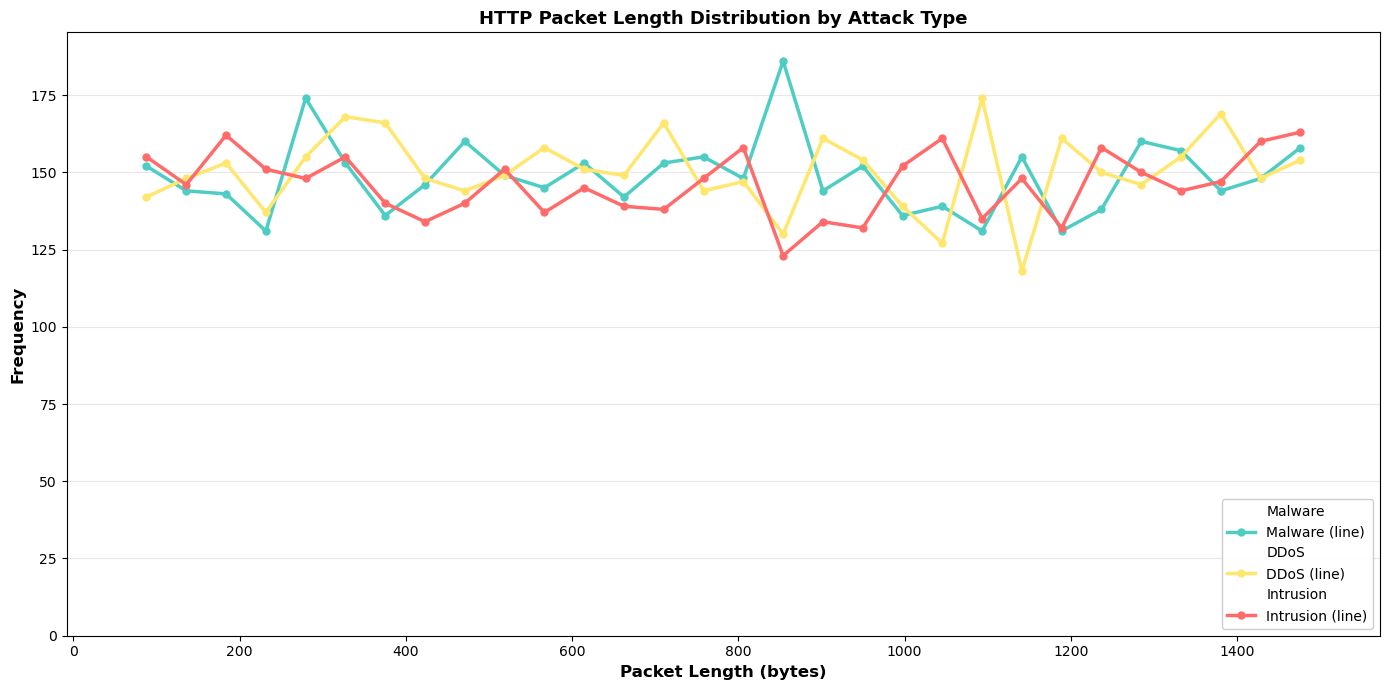

In [52]:
filter = df['Traffic Type'] == 'HTTP'
ftp_data = df.loc[filter].copy()

# Get unique attack types
attack_types = ftp_data['Attack Type'].unique()

# Define colors for each attack type
colors = {'Intrusion': '#FF6B6B', 'Malware': '#4ECDC4', 'DDoS': '#FFE66D'}

# Create single plot with all attack types
fig, ax = plt.subplots(figsize=(14, 7))

# Plot each attack type with line overlay only
for attack in attack_types:
    data = ftp_data.loc[ftp_data['Attack Type'] == attack, 'Packet Length']
    
    # Create histogram to get counts and bins
    counts, bins, patches = ax.hist(data, bins=30, alpha=0.0, 
                                     label=f'{attack}', 
                                     color=colors.get(attack, 'blue'))
    
    # Line plot overlay connecting histogram centers
    bin_centers = (bins[:-1] + bins[1:]) / 2
    ax.plot(bin_centers, counts, color=colors.get(attack, 'blue'), 
            linewidth=2.5, marker='o', markersize=5, 
            label=f'{attack} (line)')

ax.set_xlabel('Packet Length (bytes)', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax.set_title('HTTP Packet Length Distribution by Attack Type', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.legend(loc='lower right', framealpha=0.95)
plt.tight_layout()
plt.show()

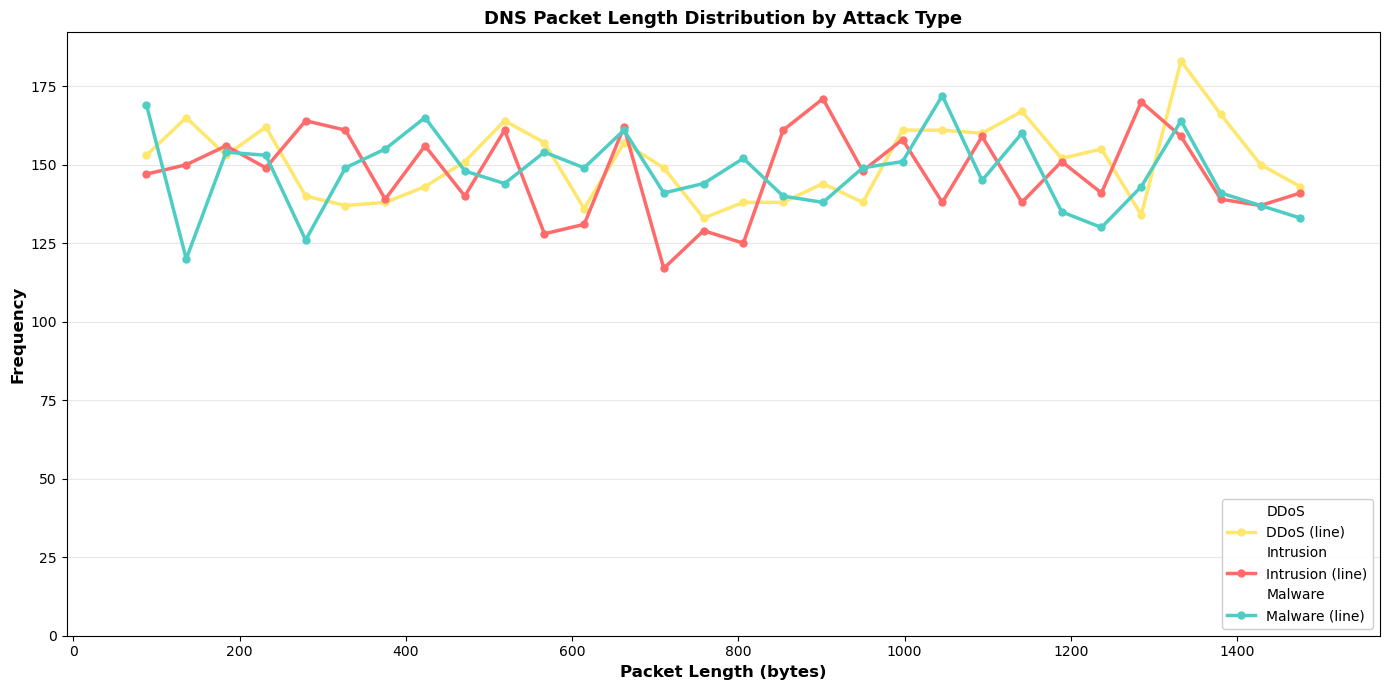

In [27]:
filter = df['Traffic Type'] == 'DNS'
ftp_data = df.loc[filter].copy()

# Get unique attack types
attack_types = ftp_data['Attack Type'].unique()

# Define colors for each attack type
colors = {'Intrusion': '#FF6B6B', 'Malware': '#4ECDC4', 'DDoS': '#FFE66D'}

# Create single plot with all attack types
fig, ax = plt.subplots(figsize=(14, 7))

# Plot each attack type with line overlay only
for attack in attack_types:
    data = ftp_data.loc[ftp_data['Attack Type'] == attack, 'Packet Length']
    
    # Create histogram to get counts and bins
    counts, bins, patches = ax.hist(data, bins=30, alpha=0.0, 
                                     label=f'{attack}', 
                                     color=colors.get(attack, 'blue'))
    
    # Line plot overlay connecting histogram centers
    bin_centers = (bins[:-1] + bins[1:]) / 2
    ax.plot(bin_centers, counts, color=colors.get(attack, 'blue'), 
            linewidth=2.5, marker='o', markersize=5, 
            label=f'{attack} (line)')

ax.set_xlabel('Packet Length (bytes)', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax.set_title('DNS Packet Length Distribution by Attack Type', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.legend(loc='lower right', framealpha=0.95)
plt.tight_layout()
plt.show()

In [10]:
filter = df['Protocol'] == 'ICMP'
ct = pd.crosstab(df.loc[filter, 'Traffic Type'], df.loc[filter, 'Attack Type'])
ct

Attack Type,DDoS,Intrusion,Malware
Traffic Type,,,
DNS,1563,1480,1470
FTP,1441,1461,1484
HTTP,1504,1519,1507


In [ ]:
# Combination CountryName_Source and Traffic Type - OK
filter = df['CountryName_Source'] == 'India'
ct_CountrySource_TrafficType_AttackType = pd.crosstab(df.loc[filter, 'Traffic Type'], df.loc[filter, 'Attack Type'], normalize='index') * 100
ct_CountrySource_TrafficType_AttackType


Attack Type,DDoS,Intrusion,Malware
Traffic Type,,,
DNS,37.356322,33.333333,29.310345
FTP,33.888889,30.555556,35.555556
HTTP,33.962264,35.849057,30.188679


In [159]:
# Combination CountryName_Source, isProxy, Traffic Type - OK
filter = (df['CountryName_Source'] == 'India') & (df['Proxy Information'] != 'noProxy')
ct_CountrySource_TrafficType_AttackType = pd.crosstab(df.loc[filter, 'Traffic Type'], df.loc[filter, 'Attack Type'], normalize='index') * 100
ct_CountrySource_TrafficType_AttackType

Attack Type,DDoS,Intrusion,Malware
Traffic Type,,,
DNS,33.333333,34.444444,32.222222
FTP,34.375000,28.125000,37.500000
HTTP,38.554217,28.915663,32.530120


In [176]:
df['CountryName_Source'].value_counts(normalize=True) * 100

CountryName_Source
United States                 40.8900
China                          9.1575
Japan                          5.4750
Germany                        3.6875
United Kingdom                 3.5500
                               ...   
Nauru                          0.0025
Montserrat                     0.0025
Heard and McDonald Islands     0.0025
Kiribati                       0.0025
Jamaica                        0.0025
Name: proportion, Length: 187, dtype: float64

In [ ]:
# CountryName_Source - OK. Only United States seems fairly distributed but not the rest of countries (tested 3-5 most frequent countries after US)
# But other countries than US is only 9% or below, noise or too fit model?
filter = df['CountryName_Source'] == 'United States'
ct_CountrySource_AttackType = df.loc[filter, 'Attack Type'].value_counts(normalize=True) * 100
ct_CountrySource_AttackType

Attack Type
DDoS         33.767425
Intrusion    33.125459
Malware      33.107117
Name: proportion, dtype: float64

In [206]:
# CountryName_Source, isProxy - OK
filter = (df['CountryName_Source'] == 'India') & (df['Proxy Information'] != 'noProxy')
ct_CountrySource_AttackType = df.loc[filter, 'Attack Type'].value_counts(normalize=True) * 100
ct_CountrySource_AttackType

Attack Type
DDoS         35.315985
Malware      34.200743
Intrusion    30.483271
Name: proportion, dtype: float64

In [166]:
# CountryName_Destination - OK
filter = df['CountryName_Destination'] == 'India'
ct_CountryDestination_AttackType = df.loc[filter, 'Attack Type'].value_counts(normalize=True) * 100
ct_CountryDestination_AttackType

Attack Type
Intrusion    39.183673
DDoS         31.836735
Malware      28.979592
Name: proportion, dtype: float64

In [172]:
# CountryName_Proxy - OK
filter = df['CountryName_Proxy'] == 'India'
ct_CountryProxy_AttackType = df.loc[filter, 'Attack Type'].value_counts(normalize=True) * 100
ct_CountryProxy_AttackType

Attack Type
Malware      38.047138
DDoS         31.986532
Intrusion    29.966330
Name: proportion, dtype: float64

In [177]:
df['ContinentName_Source'].value_counts(normalize=True) * 100

ContinentName_Source
North America     43.9050
Asia              25.1125
Europe            21.1800
South America      4.2250
Africa             3.0300
Oceania            1.6525
not identified     0.8925
Antarctica         0.0025
Name: proportion, dtype: float64

In [187]:
# ContinentName_Source - OK
filter = (df['ContinentName_Source'] == 'Asia') & (df['Proxy Information'] != 'noProxy')
ct = df.loc[filter, 'Attack Type'].value_counts(normalize=True) * 100
ct

Attack Type
DDoS         33.379067
Intrusion    33.320267
Malware      33.300666
Name: proportion, dtype: float64

In [ ]:
# Plot OS_family vs Attack Type (stacked bar for top N browser families)
# create a contingency table: rows = Browser_family, columns = Attack Type
ct = pd.crosstab(df['OS_family'], df['Attack Type'])

# show full table (or limit to top N browser families by total count)
top_n = 10
top_browsers = ct.sum(axis=1).sort_values(ascending=False).head(top_n).index
ct_top = ct.loc[top_browsers]

# display table
ct_top

# stacked bar plot for the top N browser families
ct_top.plot(kind='bar', stacked=True, figsize=(12,6))
plt.xlabel('OS family')
plt.ylabel('Count')
plt.title(f'OS family vs Attack Type (top {top_n} OS families)')
plt.legend(title='Attack Type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
# Plot Source Port_Cat vs Attack Type (stacked bar for top N browser families)
# create a contingency table: rows = Browser_family, columns = Attack Type
ct = pd.crosstab(df['Source Port_Cat'], df['Attack Type'])

# show full table (or limit to top N browser families by total count)
# top_n = 10
top_browsers = ct.sum(axis=1).sort_values(ascending=False).head(top_n).index
ct_top = ct.loc[top_browsers]

# display table
ct_top

# stacked bar plot for the top N browser families
ct_top.plot(kind='bar', stacked=True, figsize=(12,6))
plt.xlabel('Source Port_Cat')
plt.ylabel('Count')
plt.title(f'Source Port_Cat vs Attack Type (top {top_n} Source Port_Cat)')
plt.legend(title='Attack Type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
df.groupby('Severity Level')['Anomaly Scores'].describe()

In [ ]:
df.groupby(['Attack Type', 'Severity Level'])['Anomaly Scores'].describe()

In [ ]:
# Fill ICMP_anomaly column: better? or no need cause anyway ICMP can be detected by Protocol feature
df['ICMP_anomaly'] = df.apply(
    lambda x: 1 if (
        x['Protocol'] == "ICMP" and (
            x['Traffic Type'] == "HTTP" or 
            x['Traffic Type'] == "DNS" or 
            x['Traffic Type'] == "FTP"
        )
    ) else 0, 
    axis=1
)

In [ ]:
df.groupby(['ICMP_anomaly', 'Traffic Type'])['Attack Type'].value_counts()

In [225]:
df_for_stats = df.copy()

In [269]:
df_for_stats['Anomaly Scores_Quartile'] = df['Anomaly Scores_Quartile']

In [ ]:
df_for_stats.drop(columns=['Timestamp', 'Source Port', 'Destination Port', 'Packet Length', 'Proxy Information', 'Browser_minor',
                 'GeoLoc_City1', 'Source IP Address_24', 'Source IP Address_16', 'Destination IP Address_24',
                 'Destination IP Address_16', 'Proxy Information_24', 'Proxy Information_16', 'CityName_Destination',
                 'CityName_Source', 'ASN_source', 'ASN_destination', 'ASN_proxy', 'Anomaly Scores'], inplace=True)

In [ ]:
# Drop Year cause doesn't really make sense for Attack Type prediction
# Drop Month and Day cos basically summary of months in different years
# Also plot of these 3 features vs Attack Type showed fair distribution
# also new columns created from time which logically might make more senses, like isWeekend, DayName
df_for_stats.drop(columns=['Year', 'Month', 'Day'], inplace=True)

In [ ]:
# Drop too specific version of device: Browser_major (66 unique values)and OS_major (22 unique values) 
# too granular, likely noise (potential overfitting?)
df_for_stats.drop(columns=['Browser_major', 'OS_major'], inplace=True)


In [301]:
df_for_stats.nunique()

Protocol                       3
Packet Type                    2
Traffic Type                   3
Malware Indicators             2
Alerts/Warnings                2
Attack Type                    3
Attack Signature               2
Action Taken                   3
Severity Level                 3
Network Segment                3
Firewall Logs                  2
IDS/IPS Alerts                 2
Log Source                     2
Browser_family                 9
OS_family                      5
Device_brand                   4
GeoLoc_City2                  28
Device_type                    4
isPrivate_Source               2
isPrivate_Destination          2
isPrivate_Proxy                3
ContinentName_Source           8
CountryName_Source           187
ContinentName_Destination      7
CountryName_Destination      180
ContinentName_Proxy            8
CountryName_Proxy            164
Source Port_Cat                2
Destination Port_Cat           2
Hours_div                      4
GeoLoc_Cou

In [307]:
for i, col in enumerate(df_for_stats.columns, 1):
    print(f"{i}. {col}")


1. Protocol
2. Packet Type
3. Traffic Type
4. Malware Indicators
5. Alerts/Warnings
6. Attack Type
7. Attack Signature
8. Action Taken
9. Severity Level
10. Network Segment
11. Firewall Logs
12. IDS/IPS Alerts
13. Log Source
14. Browser_family
15. OS_family
16. Device_brand
17. GeoLoc_City2
18. Device_type
19. isPrivate_Source
20. isPrivate_Destination
21. isPrivate_Proxy
22. ContinentName_Source
23. CountryName_Source
24. ContinentName_Destination
25. CountryName_Destination
26. ContinentName_Proxy
27. CountryName_Proxy
28. Source Port_Cat
29. Destination Port_Cat
30. Hours_div
31. GeoLoc_Country
32. GeoLoc_Country1
33. Packet_Length_Quartile
34. Day_Number
35. Is_Weekend
36. Anomaly Scores_Quartile


In [302]:
from dython.nominal import associations

# Compute correlation matrix (handles mixed data types)
# Returns Cramér's V for categorical, Pearson for numerical
correlation_matrix = associations(
    df, 
    compute_only=True,
    figsize=(20, 20)  # If you want visualization too
)["corr"]

print(correlation_matrix)

MemoryError: Unable to allocate 11.9 GiB for an array with shape (1597520177,) and data type float64

In [ ]:
df.corr(numeric_only=True)

In [ ]:
cols_to_check = [
    "Attack Signature",
    "Severity Level",
    "Action Taken",
    "IDS/IPS Alerts",
    "Malware Indicators",
    "Alerts/Warnings",
    "Network Segment",
    "Firewall Logs",
    "Log Source"
]
for col in cols_to_check:
    print(f"\n--- {col} ---")
    print(df.groupby('Attack Type')[col].value_counts(dropna=False))

In [ ]:
# doesn't show spike of Blocked if Severity Level is High
df.groupby(['Attack Type', 'Severity Level'])['Action Taken'].value_counts()

In [ ]:
# Doesn't show that IDS/IPS Alert trigger Alerts/Warnings
df.groupby('IDS/IPS Alerts')['Alerts/Warnings'].value_counts(dropna=False)

In [ ]:
# Doesn't show that certain signature is assigned to attack type
df.groupby('Attack Type')['Attack Signature'].value_counts(dropna=False)